# Script A - South Carolina: 2022 House Election
Mapping Democracy: Quantifying Ethnolinguistic Gerrymandering Through the Lens of the Modifiable Areal Unit Problem

Kuba Kowalski - 1012340 - 15/01/2026


Thesis Report GIRS-2025-71, Thesis code number: GRS-80436

Supervisor: Dr. Jennifer Koch

## Description of Notebook
This notebook consists of 4 sections:
- Section 1 sets the global environment and creates the intermediate datasets.
- Section 2 runs the simulation for the 2026 Texas Midterms using proxy data.
- Section 3 creates the main visualizations for the results chapter of the thesis report.
- Section 4 creates the secondary visualizations for other chapters of the thesis report. 

Each section starts by setting the input and outputs paths, and imports the necessary packages. 

Runtime is roughly 1h with following hardware: 
- CPU: Intel Core i9-14900KF
- RAM: 64 GB (Corsair Vengeance DDR5 32x2)
- GPU: NVIDIA GeForce RTX 4080 Super

## 1. Aggregation

The purpose of the cells below is to import the necessary packages, set the paths for inputs and outputs, and define the functions used to create the intermediate dataset that aggregates demographic and election outcome data on the level of voting tabulation districts.

In [1]:
# Packages
import sys
import re
import numpy as np
import pandas as pd
import pyogrio ## Used for read function because gpd clashes with input datasets for some reason
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as mcm
import ipywidgets as widgets

from pathlib import Path
from IPython.display import display, clear_output
from functools import partial
from gerrychain import Graph, Partition, updaters, accept, MarkovChain
from gerrychain.proposals import recom
from gerrychain.tree import recursive_tree_part
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain import Election
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias
from gerrychain import Graph, Partition
from gerrychain.updaters import Election, Tally, cut_edges
from gerrychain.updaters.geo import geo_updater

In [2]:
# Paths

## Inputs
VTD_FP    = r"./inputs/SC/tiger_tl_2020_45_vtd20/tl_2020_45_vtd20.shp"                          # TIGER 2020 VTDs
VEST_FP   = r"./inputs/SC/sc_2022_gen_prec/sc_2022_gen_cong_prec/sc_2022_gen_cong_prec.shp"     # VEST 2020 precincts with votes
BLOCKS_SRC = r"./inputs/SC/nhgis0002_shape/SC_block_2020.shp"                                   # block shapefile for join with csv
NHGIS_CSV  = r"./inputs/SC/nhgis0006_csv/nhgis0006_ds258_2020_block.csv"                        # pop table
BLOCKS_FP = r"./inputs/SC/SC_block/SC_block_2020_withpop.shp"                                   # Created in code block above
S865_FP = r"./inputs/SC/sc_cong_adopted_2022/S865_Congress.shp"                                 # needed for District tagging, congressional district plan S.865 discussed in Alexander

## final outputs
OUT_GPKG  = "./outputs/SC22/SC_vtds_2022_final.gpkg"
OUT_SHP   = "./outputs/SC22/SC_vtds_2022_final.shp"
LAYER     = "vtds_2022"
OUT_LAYER = "blocks_2020"

In [3]:
# load blocks
src = str(BLOCKS_SRC)
if src.lower().endswith(".zip"):
    # auto-pick the block layer inside the ZIP
    layers = pyogrio.list_layers(src)
    # look for a layer ending with "_2020" or containing "block" (NHGIS naming)
    layer_name = None
    for name, *_ in layers:
        if re.search(r"block.*2020", name, re.I) or name.lower().endswith("_2020"):
            layer_name = name
            break
    if layer_name is None:
        layer_name = layers[0][0]  # fallback to the first layer
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src, layer=layer_name))
else:
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src))

print("Loaded raw blocks:", len(blocks))

# read CSV 
df = pd.read_csv(NHGIS_CSV, dtype=str)

# restrict to South Carolina
if "STATEA" in blocks.columns:
    blocks = blocks.loc[blocks["STATEA"] == "45"].copy()

# --- pickNHGIS columns (U7H001 = P1 Total population)
keep_cols = ["GISJOIN", "U7H001"]  # ability to add more columns if needed, keep
df = df[keep_cols].copy()
df["GISJOIN"] = df["GISJOIN"].str.strip()
df = df.rename(columns={"U7H001": "TOTPOP"})
df["TOTPOP"] = pd.to_numeric(df["TOTPOP"], errors="coerce")

# join 
gdf = blocks.merge(df, on="GISJOIN", how="left")

# validation, if missing > 0 -> redo
n_blocks   = len(gdf)
n_missing  = int(gdf["TOTPOP"].isna().sum())
state_total = int(gdf["TOTPOP"].fillna(0).sum())
print(f"Blocks: {n_blocks:,} | missing TOTPOP after join: {n_missing:,}")
print(f"South Carolina total (sum TOTPOP): {state_total:,}")

# write GPKG 
Path(OUT_GPKG).parent.mkdir(parents=True, exist_ok=True)
pyogrio.write_dataframe(gdf, OUT_GPKG, driver="GPKG", layer=OUT_LAYER)
print("Wrote:", OUT_GPKG)
blocks_withpop = gpd.GeoDataFrame(pyogrio.read_dataframe(OUT_GPKG, layer=OUT_LAYER))
print("Loaded rows:", len(blocks_withpop))

Loaded raw blocks: 145955
Blocks: 145,955 | missing TOTPOP after join: 0
South Carolina total (sum TOTPOP): 5,118,419
Wrote: ./outputs/SC22/SC_vtds_2022_final.gpkg
Loaded rows: 145955


In [4]:
# Functions

## Repairing geometry in input data using buffer method. 
def clean(g):
    g["geometry"] = g.geometry.make_valid().buffer(0)
    g = g.explode(index_parts=False, ignore_index=True)
    g = g[~g.geometry.is_empty].copy()
    return g

## Aggregating population (blocks) and electoral outcomes (precincts) into voting tabulation districts (VTDs) using the area weighting method
def area_weight_allocate(source_gdf, target_gdf, value_cols, source_id_col):
    """Area-weight allocate source value_cols onto targets. Renormalizes per source."""
    
    ## Indexes blocks/precincts and stores area for weighting
    src = source_gdf.reset_index(drop=False).rename(columns={"index":"__src_id"})
    if "__src_area" not in src:
        src["__src_area"] = src.geometry.area

    ## Computes intersection area of blocks/precincts and VTDs
    inter = gpd.overlay(
        src[[source_id_col, "__src_id", "__src_area", *value_cols, "geometry"]],
        target_gdf[["__TARGET_ID__", "geometry"]],
        how="intersection"
    )
    inter["__int_area"] = inter.geometry.area
    inter["__w"] = (inter["__int_area"] / inter["__src_area"]).replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)

    ## If a block/precinct has no intersection, buffer it slightly to force an overlap with a VTD and calculate intersection area
    hit_src = set(inter["__src_id"])
    missing_src = sorted(set(src["__src_id"]) - hit_src)
    if missing_src:
        miss = src.loc[src["__src_id"].isin(missing_src), [source_id_col, "__src_id","__src_area", *value_cols, "geometry"]].copy() ## miss = blocks/precincts without VTD overlap
        miss["geometry"] = miss.geometry.buffer(2)  # 2 meters in EPSG:5070
        inter2 = gpd.overlay(miss, target_gdf[["__TARGET_ID__", "geometry"]], how="intersection")
        inter2["__int_area"] = inter2.geometry.area
        inter2["__w"] = (inter2["__int_area"] / inter2["__src_area"]).replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)
        inter = pd.concat([inter, inter2], ignore_index=True) ## Appends new interactions to the results previous part of function

    ## Ensures weights sum to 1.0
    wsum = inter.groupby("__src_id")["__w"].transform("sum").replace(0, np.nan)
    inter["__w_norm"] = (inter["__w"] / wsum).fillna(0).clip(0, 1)

    ## Applies calculated weights to population and voting outcome columns
    for c in value_cols:
        inter[c + "_w"] = pd.to_numeric(inter[c], errors="coerce").fillna(0.0) * inter["__w_norm"]

    ## sSums weighted contributions to each VTD
    agg = inter.groupby("__TARGET_ID__", as_index=False)[[c + "_w" for c in value_cols]].sum()
    return agg.rename(columns={c + "_w": c for c in [*value_cols]})

## Generating initial districting plan 
def make_seed(graph, k, ideal, pop_col="TOTPOP"):
    def seed(eps):
        return recursive_tree_part(
            graph,
            parts=range(k),
            pop_target=ideal,
            pop_col=pop_col,
            epsilon=eps
        )
    return seed


In [5]:
# Loading input 
vtd    = gpd.GeoDataFrame(pyogrio.read_dataframe(VTD_FP))
vest   = gpd.GeoDataFrame(pyogrio.read_dataframe(VEST_FP))
blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(OUT_GPKG))

# projection
print("CRS:", vtd.crs, vest.crs, blocks.crs)
TARGET_CRS = 5070  # NAD83 / Conus Albers (meters)
assert vtd.crs and vest.crs and blocks.crs, "All inputs need a CRS."

def clean(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.make_valid().buffer(0)
    gdf = gdf.explode(index_parts=False, ignore_index=True)
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf

# Apply correct projection
vtd    = vtd.to_crs(TARGET_CRS)
vest   = vest.to_crs(TARGET_CRS)
blocks = blocks.to_crs(TARGET_CRS)

# Repairs geometry
vtd = clean(vtd)
vest = clean(vest)
blocks = clean(blocks)

c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'SC_vtds_2022_final.gpkg': 'vtds_2022' (default), 'blocks_2020'. Specify layer parameter to avoid this warning.
  result = read_func(


CRS: EPSG:4269 EPSG:2273 EPSG:5070


In [6]:
# Setting up VTD dataset for aggregation
# Not using a fixed column name so the notebook stays reusable (TX)
vtd_id_candidates = [c for c in vtd.columns if re.fullmatch(r"(?i)GEOID20", c)] \
    or [c for c in vtd.columns if c.upper() in {"GEOID", "GEOID10", "VTD", "VTDST20"}]  # Looks for VTD identifier
assert vtd_id_candidates, "Couldn't find a VTD ID (e.g., GEOID20)."
VTD_ID = vtd_id_candidates[0]

# Dissolve by VTD ID to ensure one polygon per VTD
vtd = vtd[[VTD_ID, "geometry"]].dissolve(by=VTD_ID, as_index=True).reset_index()
vtd["geometry"] = vtd.geometry.buffer(0)  # Fix small topology issues
vtd["__TARGET_ID__"] = vtd[VTD_ID]        # Used by area_weight_allocate()

# Demographic data: blocks to VTD

# Check for population columns
POP_COL_BLOCK = None
for cand in ["P1_001N", "P001001", "TOTPOP", "TOT_POP", "POP"]:
    if cand in blocks.columns:
        POP_COL_BLOCK = cand
        break
assert POP_COL_BLOCK, "Block layer must have total population column (e.g., P1_001N)."

# Ensure population column is numeric
blocks[POP_COL_BLOCK] = pd.to_numeric(blocks[POP_COL_BLOCK], errors="coerce").fillna(0.0)

# Check for ID column 
blk_id = None
for cand in ["GEOID20", "GEOID", "BLOCKID", "BLOCKID20"]:
    if cand in blocks.columns:
        blk_id = cand
        break
if blk_id is None:
    blocks["__blk_id__"] = np.arange(len(blocks))
    blk_id = "__blk_id__"

# Aggregating demographic data from blocks to VTDs (area-weighted)
pop_agg = area_weight_allocate(
    source_gdf=blocks,
    target_gdf=vtd[["__TARGET_ID__", "geometry"]].copy(),
    value_cols=[POP_COL_BLOCK],
    source_id_col=blk_id,
).rename(columns={POP_COL_BLOCK: "TOTPOP"})



# Vote totals – SC 2022 congressional election
# (standardized to PRES20 names to keep TX code interchangeable)

# Identify SC 2022 US House vote columns (GCON01–GCON07)
dem_cols = [c for c in vest.columns if re.fullmatch(r"GCON\d{2}D.*", c)]
rep_cols = [c for c in vest.columns if re.fullmatch(r"GCON\d{2}R.*", c)]
oth_cols = [c for c in vest.columns if re.fullmatch(r"GCON\d{2}OWRI", c)]

assert dem_cols and rep_cols, "No 2022 US House DEM/REP columns detected in precinct file."

# Ensure numeric 
for c in dem_cols + rep_cols + oth_cols:
    vest[c] = pd.to_numeric(vest[c], errors="coerce").fillna(0.0)

# Standardized TX output fields
vest["PRES20D"]   = vest[dem_cols].sum(axis=1)
vest["PRES20R"]   = vest[rep_cols].sum(axis=1)
vest["PRES20OTH"] = vest[oth_cols].sum(axis=1)
vest["TOTTO20"]   = vest["PRES20D"] + vest["PRES20R"] + vest["PRES20OTH"]


# Precinct ID and area-weighted aggregation: precincts -> VTD
# Pick a valid ID column from VEST
id_candidates = ["PCODE", "VTD", "PRECINCT", "GEOID", "GISJOIN"]
for c in id_candidates:
    if c in vest.columns:
        source_id_col_vest = c
        break
else:
    vest["__prec_id"] = np.arange(len(vest))
    source_id_col_vest = "__prec_id"

# Aggregate vote totals using area-weighted allocation
votes_agg = area_weight_allocate(
    source_gdf=vest,
    target_gdf=vtd[["__TARGET_ID__", "geometry"]].copy(),
    value_cols=["PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"],
    source_id_col=source_id_col_vest,
)


# Join aggregated vote and population totals to VTDs
out = (
    vtd.merge(pop_agg, on="__TARGET_ID__", how="left")
       .merge(votes_agg, on="__TARGET_ID__", how="left")
)

# Set all missing values after join to 0 -> prevents errors downstream. Beware of division by 0 problems. 
for c in ["TOTPOP", "PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"]:
    if c in out.columns:
        out[c] = out[c].fillna(0.0)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\One

In [7]:
# Validation of Aggregation Results 
src_pop_sum  = float(blocks[POP_COL_BLOCK].sum())              # total in census blocks (source)
vtd_pop_sum  = float(out["TOTPOP"].sum())                      # aggregated total
src_vote_sum = vest[["PRES20D","PRES20R","PRES20OTH","TOTTO20"]].sum()  # total in precincts (source)
vtd_vote_sum = out[["PRES20D","PRES20R","PRES20OTH","TOTTO20"]].sum()   # aggregated total

print("POP totals diff:", vtd_pop_sum - src_pop_sum)  # should be near 0
print(pd.DataFrame({"source": src_vote_sum, "vtd": vtd_vote_sum, "diff": vtd_vote_sum - src_vote_sum}))


# Geometry fields in case they're missing
out["AREA"]  = out.geometry.area / 1_000_000  # km²
out["PERIM"] = out.geometry.length / 1_000    # km

# Vote share & margin (still using TX-style names)
out["PRES20_2P"] = out["PRES20D"] + out["PRES20R"]
out["DEM20_SHARE"] = out["PRES20D"] / out["PRES20_2P"].replace(0, np.nan)

out["DEM20_MARGIN"] = out["DEM20_SHARE"] - (
    out["PRES20R"] / out["PRES20_2P"].replace(0, np.nan)
)
# > 0  Dems won
# < 0  Reps won

# Tag VTDs with district from S.865 (Alexander plan) for later aggregation
try:
    # Read S.865 plan and reproject to match VTDs
    cd = gpd.GeoDataFrame(
        pyogrio.read_dataframe(
            S865_FP,
            bbox=tuple(map(float, out.total_bounds))
        )
    ).to_crs(out.crs)
    
    # Optional: filter to South Carolina if layer were multi-state
    if "STATEFP" in cd.columns:
        cd = cd[cd["STATEFP"] == "45"].copy()  # 45 = SC

    # Pick the district ID column in S865
    dist_col_candidates = ["District", "DISTRICT", "CD", "CD116", "CDIST", "USCD"]
    dist_col = None
    for c in dist_col_candidates:
        if c in cd.columns:
            dist_col = c
            break
    assert dist_col is not None, "Could not find a district column in S865 shapefile."

    # pick points for spatial join
    pts = out.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(out[[VTD_ID]].copy(), geometry=pts, crs=out.crs)
    
    tag = gpd.sjoin(
        pts_gdf,
        cd[[dist_col, "geometry"]],
        predicate="within",
        how="left",
    ).rename(columns={dist_col: "USCD"})[[VTD_ID, "USCD"]]

    out = out.merge(tag, on=VTD_ID, how="left")
    out["USCD"] = out["USCD"].astype(str)

except Exception as e:
    print("USCD tagging (S865) skipped:", e)

# Export
pyogrio.write_dataframe(out, OUT_GPKG, layer=LAYER) 
pyogrio.write_dataframe(out, OUT_SHP)              

print("Rows:", len(out), "Columns:", list(out.columns)[:12], "…")
print("Example totals:", {
    "TOTPOP":  int(out["TOTPOP"].sum()),
    "PRES20D": int(out["PRES20D"].sum()),
    "PRES20R": int(out["PRES20R"].sum()),
    "TOTTO20": int(out["TOTTO20"].sum()),
})


POP totals diff: 3.725290298461914e-09
            source        vtd  diff
PRES20D     549020   549020.0   0.0
PRES20R    1094781  1094781.0   0.0
PRES20OTH    23464    23464.0   0.0
TOTTO20    1667265  1667265.0   0.0


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Rows: 2268 Columns: ['GEOID20', 'geometry', '__TARGET_ID__', 'TOTPOP', 'PRES20D', 'PRES20R', 'PRES20OTH', 'TOTTO20', 'AREA', 'PERIM', 'PRES20_2P', 'DEM20_SHARE'] …
Example totals: {'TOTPOP': 13700692, 'PRES20D': 549020, 'PRES20R': 1094781, 'TOTTO20': 1667265}


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '__TARGET_ID__' to '__TARGET_I'
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'DEM20_SHARE' to 'DEM20_SHAR'
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'DEM20_MARGIN' to 'DEM20_MARG'
  ogr_write(


## Simulation

In [ ]:
# GEO metric

def _district_neighbors_from_cut_edges(partition):
    """Fast district adjacency using the cut_edges updater if present."""
    neighbors = defaultdict(set)
    cut_edges = partition["cut_edges"]
    assignment = partition.assignment
    for u, v in cut_edges:
        a, b = assignment[u], assignment[v]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
    for d in partition.parts.keys():
        neighbors.setdefault(d, set())
    return {d: sorted(n) for d, n in neighbors.items()}

def _district_neighbors_from_all_edges(partition):
    """Fallback: build district adjacency by scanning all graph edges."""
    neighbors = defaultdict(set)
    assignment = partition.assignment
    for u, v in partition.graph.edges():
        a, b = assignment[u], assignment[v]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
    for d in partition.parts.keys():
        neighbors.setdefault(d, set())
    return {d: sorted(n) for d, n in neighbors.items()}

def _district_neighbors(partition):
    if "cut_edges" in partition.updaters:
        return _district_neighbors_from_cut_edges(partition)
    return _district_neighbors_from_all_edges(partition)

def geo_metric_for_partition(partition, election_name, party=None, min_cvs=0.50, max_cvs=0.55):
    """
    GEO score for `party` in `election_name` on the current Partition.

    Returns: int (number of newly-competitive districts for `party`).
    """
    election = partition[election_name]
    if party is None:
        party = election.parties[0]

    districts = list(partition.parts.keys())
    neighbors = _district_neighbors(partition)

    # Initial vote shares 
    shares = {}
    for d in districts:
        s = election.percents_for_party[party].get(d, 0.0)
        if s is None or (isinstance(s, float) and math.isnan(s)):
            s = 0.0
        shares[d] = float(s)

    rec = {
        d: {
            "orig": shares[d],
            "vs": shares[d],
            "Ai": 0.0,
            "vshare": 0.0,
            "made_competitive": False,
            "is_competitive": False,
            "total_shared": 0.0,
        }
        for d in districts
    }

    # A_i
    for d in districts:
        neigh = neighbors[d]
        total = rec[d]["vs"] + sum(rec[n]["vs"] for n in neigh)
        rec[d]["Ai"] = total / (len(neigh) + 1)

    # std(A_i) (sample stdev like pandas)
    A_vals = [rec[d]["Ai"] for d in districts]
    sd = stdev(A_vals) if len(A_vals) >= 2 else 0.0
    win_adj = sd
    loss_adj = sd

    # votes-to-share + competitiveness
    for d in districts:
        vs, Ai = rec[d]["vs"], rec[d]["Ai"]
        if vs > max_cvs:
            rec[d]["vshare"] = max(0.0, vs - max(max_cvs, Ai - win_adj))
        elif vs >= min_cvs:
            rec[d]["vshare"] = 0.0
            rec[d]["is_competitive"] = True
        else:
            rec[d]["vshare"] = max(0.0, vs - (Ai - loss_adj))

    # order by A_i desc
    ordered = sorted(districts, key=lambda d: rec[d]["Ai"], reverse=True)
    stable_win = [d for d in ordered if rec[d]["vs"] > max_cvs]
    loss = [d for d in ordered if rec[d]["vs"] < min_cvs]
    stable_win_loss = stable_win + loss  # keep this order

    # make losing districts competitive using proportional transfers
    newly_comp = []
    for j in loss:
        need = min_cvs - rec[j]["vs"]
        if need <= 0:
            continue

        shareables = [k for k in neighbors[j] if k in stable_win_loss]
        neigh_supply = sum(rec[k]["vshare"] for k in shareables)

        if need <= neigh_supply:
            rec[j]["vs"] = min_cvs
            rec[j]["vshare"] = 0.0
            rec[j]["is_competitive"] = True
            rec[j]["made_competitive"] = True
            newly_comp.append(j)
            if j in stable_win_loss:
                stable_win_loss.remove(j)

            for k in shareables:
                supply_k = rec[k]["vshare"]
                if supply_k <= 0:
                    continue
                take = (supply_k / neigh_supply) * need
                rec[k]["vs"] -= take
                rec[k]["vshare"] -= take
                rec[k]["total_shared"] += take

    return sum(1 for d in districts if rec[d]["made_competitive"])

def geo_updater(election_name, party=None, min_cvs=0.50, max_cvs=0.55):
    """Updater factory: returns a function(partition) -> int (GEO score)."""
    def _geo(partition):
        return geo_metric_for_partition(
            partition,
            election_name=election_name,
            party=party,
            min_cvs=min_cvs,
            max_cvs=max_cvs,
        )
    return _geo

In [8]:
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, pyogrio
from gerrychain import Graph, updaters
from gerrychain.updaters import Election

# Inputs: SC VTD file from above
VTD_GPKG = Path("./outputs/SC22/SC_vtds_2022_final.gpkg")
VTD_LAYER = "vtds_2020"   # same LAYER name you used when writing OUT_GPKG

if not VTD_GPKG.exists():
    raise FileNotFoundError(f"SC VTD gpkg not found: {VTD_GPKG}")

# Load VTDs
gdf = gpd.read_file(VTD_GPKG, layer="vtds_2022", engine="pyogrio")

# Ensure GEOID20 exists
if "GEOID20" not in gdf.columns:
    if "GEOID" in gdf.columns:
        gdf["GEOID20"] = gdf["GEOID"].astype(str)
    elif VTD_ID in gdf.columns:     # fallback: use the ID we used earlier
        gdf["GEOID20"] = gdf[VTD_ID].astype(str)
    else:
        raise KeyError("VTD layer lacks GEOID20/GEOID/VTD_ID; need a unique VTD ID column.")

# make sure key fields exist & are numeric
for col in ["TOTPOP", "PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"]:
    if col in gdf.columns:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce").fillna(0).astype(int)
    else:
        print(f"[warn] {col} not found in gdf.columns")

# re-set projected CRS
SC_PROJECTED = "EPSG:5070"   # NAD83 / Conus Albers (same as preprocessing)

# fix invalid geometries
gdf["geometry"] = gdf.geometry.buffer(0)

if gdf.crs is None:
    raise ValueError("gdf has no CRS; set it before reprojecting (e.g. EPSG:4269).")

if gdf.crs.to_epsg() != 5070:
    gdf = gdf.to_crs(SC_PROJECTED)

# Build graph & updaters (PRES20 alias = SC 2022 US House)
graph = Graph.from_geodataframe(gdf, adjacency="rook")

my_updaters = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": updaters.cut_edges,
}

# Use the same PRES20 alias the TX code expects, but here it means SC 2022 US House
if {"PRES20D", "PRES20R"}.issubset(gdf.columns):
    my_updaters["votes20"] = updaters.Tally(["PRES20D", "PRES20R"], alias="votes20")
    my_updaters["PRES20"]  = Election("PRES20", {"D": "PRES20D", "R": "PRES20R"})

# --- Number of districts in SC CD plan ---
k = 7  # SC has 7 congressional districts
ideal = gdf["TOTPOP"].sum() / k

print(f"Loaded SC VTDs: {len(gdf)} | k={k} | ideal ≈ {ideal:,.0f}")
print("Columns available:", list(gdf.columns)[:20], "...")


Loaded SC VTDs: 2268 | k=7 | ideal ≈ 1,957,082
Columns available: ['GEOID20', '__TARGET_ID__', 'TOTPOP', 'PRES20D', 'PRES20R', 'PRES20OTH', 'TOTTO20', 'AREA', 'PERIM', 'PRES20_2P', 'DEM20_SHARE', 'DEM20_MARGIN', 'USCD', 'geometry'] ...


## 2. simulation

In [17]:
# GEO metric

def _district_neighbors_from_cut_edges(partition):
    """Fast district adjacency using the cut_edges updater if present."""
    neighbors = defaultdict(set)
    cut_edges = partition["cut_edges"]
    assignment = partition.assignment
    for u, v in cut_edges:
        a, b = assignment[u], assignment[v]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
    for d in partition.parts.keys():
        neighbors.setdefault(d, set())
    return {d: sorted(n) for d, n in neighbors.items()}

def _district_neighbors_from_all_edges(partition):
    """Fallback: build district adjacency by scanning all graph edges."""
    neighbors = defaultdict(set)
    assignment = partition.assignment
    for u, v in partition.graph.edges():
        a, b = assignment[u], assignment[v]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
    for d in partition.parts.keys():
        neighbors.setdefault(d, set())
    return {d: sorted(n) for d, n in neighbors.items()}

def _district_neighbors(partition):
    if "cut_edges" in partition.updaters:
        return _district_neighbors_from_cut_edges(partition)
    return _district_neighbors_from_all_edges(partition)

def geo_metric_for_partition(partition, election_name, party=None, min_cvs=0.50, max_cvs=0.55):
    """
    GEO score for `party` in `election_name` on the current Partition.

    Returns: int (number of newly-competitive districts for `party`).
    """
    election = partition[election_name]
    if party is None:
        party = election.parties[0]

    districts = list(partition.parts.keys())
    neighbors = _district_neighbors(partition)

    # Initial vote shares 
    shares = {}
    for d in districts:
        s = election.percents_for_party[party].get(d, 0.0)
        if s is None or (isinstance(s, float) and math.isnan(s)):
            s = 0.0
        shares[d] = float(s)

    rec = {
        d: {
            "orig": shares[d],
            "vs": shares[d],
            "Ai": 0.0,
            "vshare": 0.0,
            "made_competitive": False,
            "is_competitive": False,
            "total_shared": 0.0,
        }
        for d in districts
    }

    # A_i
    for d in districts:
        neigh = neighbors[d]
        total = rec[d]["vs"] + sum(rec[n]["vs"] for n in neigh)
        rec[d]["Ai"] = total / (len(neigh) + 1)

    # std(A_i) (sample stdev like pandas)
    A_vals = [rec[d]["Ai"] for d in districts]
    sd = stdev(A_vals) if len(A_vals) >= 2 else 0.0
    win_adj = sd
    loss_adj = sd

    # votes-to-share + competitiveness
    for d in districts:
        vs, Ai = rec[d]["vs"], rec[d]["Ai"]
        if vs > max_cvs:
            rec[d]["vshare"] = max(0.0, vs - max(max_cvs, Ai - win_adj))
        elif vs >= min_cvs:
            rec[d]["vshare"] = 0.0
            rec[d]["is_competitive"] = True
        else:
            rec[d]["vshare"] = max(0.0, vs - (Ai - loss_adj))

    # order by A_i desc
    ordered = sorted(districts, key=lambda d: rec[d]["Ai"], reverse=True)
    stable_win = [d for d in ordered if rec[d]["vs"] > max_cvs]
    loss = [d for d in ordered if rec[d]["vs"] < min_cvs]
    stable_win_loss = stable_win + loss  # keep this order

    # make losing districts competitive using proportional transfers
    newly_comp = []
    for j in loss:
        need = min_cvs - rec[j]["vs"]
        if need <= 0:
            continue

        shareables = [k for k in neighbors[j] if k in stable_win_loss]
        neigh_supply = sum(rec[k]["vshare"] for k in shareables)

        if need <= neigh_supply:
            rec[j]["vs"] = min_cvs
            rec[j]["vshare"] = 0.0
            rec[j]["is_competitive"] = True
            rec[j]["made_competitive"] = True
            newly_comp.append(j)
            if j in stable_win_loss:
                stable_win_loss.remove(j)

            for k in shareables:
                supply_k = rec[k]["vshare"]
                if supply_k <= 0:
                    continue
                take = (supply_k / neigh_supply) * need
                rec[k]["vs"] -= take
                rec[k]["vshare"] -= take
                rec[k]["total_shared"] += take

    return sum(1 for d in districts if rec[d]["made_competitive"])

def geo_updater(election_name, party=None, min_cvs=0.50, max_cvs=0.55):
    """Updater factory: returns a function(partition) -> int (GEO score)."""
    def _geo(partition):
        return geo_metric_for_partition(
            partition,
            election_name=election_name,
            party=party,
            min_cvs=min_cvs,
            max_cvs=max_cvs,
        )
    return _geo


In [ ]:
# ReCom chain with AUS
import numpy as np, pandas as pd, random, networkx as nx, geopandas as gpd
from pathlib import Path
from functools import partial

from gerrychain import Graph, Partition, accept, MarkovChain
from gerrychain.updaters import Tally, Election, cut_edges
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain.proposals import recom
from gerrychain.tree import recursive_tree_part
from gerrychain.metrics import (
    mean_median as gc_mean_median,
    efficiency_gap as gc_efficiency_gap,
    partisan_bias as gc_partisan_bias,
)

# prerequisites 
assert "gdf" in globals(), "Expected a VTD GeoDataFrame `gdf` with TOTPOP (and votes) already loaded."
assert "TOTPOP" in gdf.columns, "gdf must have TOTPOP."
assert "geometry" in gdf.columns, "gdf must have geometry."
assert "precompute_tilde_pi" in globals() and "make_areal_unit_segregation_updater" in globals(), \
    "Run the cell that defines precompute_tilde_pi(...) and make_areal_unit_segregation_updater(...) first."

HAS_VOTES = {"PRES20D", "PRES20R"}.issubset(gdf.columns)
if not HAS_VOTES:
    raise ValueError("gdf must contain PRES20D and PRES20R for fairness metrics / seats.")

# config
GROUP_KEY   = "NONWHITE"
TOTAL_STEPS = 10_000
POP_TOL     = 0.01
K_DEFAULT   = 7

out_dir       = Path("./outputs/SC22")
OUT_SUMMARY   = out_dir / "sc_vtds_recom_summary_aus_fairness.csv"
OUT_PLAN_GPKG = out_dir / "sc_2022_sample_plan_with_aus_fairness.gpkg"
OUT_PLAN_SHP  = out_dir / "sc_2022_sample_plan_with_aus_fairness.shp"

TARGET_STEP_EXPORT = 9999
plan_0_path    = out_dir / "sc_2022_sample_plan_0D.gpkg"
plan_2_path    = out_dir / "sc_2022_sample_plan_2D.gpkg"
plan_4_path    = out_dir / "sc_2022_sample_plan_4D.gpkg"
plan_9999_path = out_dir / "sc_2022_sample_plan_step9999.gpkg"

# A + B exports
out_dir.mkdir(parents=True, exist_ok=True)

# A: table
SAVE_ASSIGNMENTS = True
SAVE_ASSIGNMENTS_EVERY = 100
ASSIGNMENTS_PARQUET = out_dir / "sc22_assignments_long.parquet"
assignments_chunks = []

# B: GPKG 
EXPORT_GEOMS = True
EXPORT_EVERY = 100
ENSEMBLE_GPKG = out_dir / "sc22_ensemble_districts.gpkg"
ENSEMBLE_LAYER = "districts"

# funcs
def _save_plan_for_step(step, gdf, assign, out_path: Path):
    gdf_plan = gdf.copy()
    gdf_plan["district"] = assign.values

    plan = (
        gdf_plan
        .dissolve(by="district", as_index=False)
        .set_geometry("geometry")
    )

    vote_cols = [c for c in ["PRES20D", "PRES20R"] if c in gdf_plan.columns]
    if vote_cols:
        votes = (
            gdf_plan
            .groupby("district")[vote_cols]
            .sum()
            .reset_index()
        )
        plan = plan.merge(votes, on="district", how="left")

    plan["step"] = step
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plan.to_file(out_path.as_posix(), driver="GPKG")
    print(f"Saved plan for step {step} to: {out_path.as_posix()}")

# ensure group column exists
if GROUP_KEY not in gdf.columns:
    raise KeyError(f"'{GROUP_KEY}' not in gdf. Available columns include: {list(gdf.columns)[:20]}")

# ensure projected CRS & clean geometries 
SC_PROJECTED = "EPSG:5070"
gdf = gdf.copy()
gdf["geometry"] = gdf.geometry.buffer(0)
if gdf.crs is None:
    raise ValueError("gdf has no CRS; set it before running.")
if gdf.crs.to_string().upper() != SC_PROJECTED:
    gdf = gdf.to_crs(SC_PROJECTED)

# build graph (rook) 
try:
    import libpysal
    gdf["__id__"] = gdf.index
    W = libpysal.weights.contiguity.Rook.from_dataframe(gdf, ids=gdf["__id__"])
    G_nx = nx.Graph()
    G_nx.add_nodes_from(gdf["__id__"])
    for i, nbrs in W.neighbors.items():
        for j in nbrs:
            if i < j:
                G_nx.add_edge(i, j)
    graph = Graph(G_nx)
    del gdf["__id__"]
    print("Graph built via libpysal rook.")
except Exception:
    graph = Graph.from_geodataframe(gdf, adjacency="rook", ignore_errors=True)
    print("Graph built via Graph.from_geodataframe (rook).")

# push attributes to nodes
nx.set_node_attributes(graph, gdf["TOTPOP"].astype(float).to_dict(), "TOTPOP")
nx.set_node_attributes(graph, gdf[GROUP_KEY].astype(float).to_dict(), GROUP_KEY)
for col in ["PRES20D", "PRES20R"]:
    nx.set_node_attributes(graph, gdf[col].astype(float).to_dict(), col)

# centroids for AUS
cent = gdf.geometry.centroid
nx.set_node_attributes(graph, dict(zip(gdf.index, zip(cent.x, cent.y))), "pos")

# updaters 
my_updaters = {
    "population": Tally("TOTPOP", alias="population"),
    "cut_edges":  cut_edges,
    "votes20":    Tally(["PRES20D", "PRES20R"], alias="votes20"),
    "PRES20":     Election("PRES20", {"D": "PRES20D", "R": "PRES20R"}),
}

# GEO
my_updaters["geo_D"] = geo_updater("PRES20", party="D", min_cvs=0.50, max_cvs=0.55)
my_updaters["geo_R"] = geo_updater("PRES20", party="R", min_cvs=0.50, max_cvs=0.55)

# fairness
def updater_efficiency_gap(partition): return float(gc_efficiency_gap(partition["PRES20"]))
def updater_mean_median(partition):    return float(gc_mean_median(partition["PRES20"]))
def updater_partisan_bias_50(partition): return float(gc_partisan_bias(partition["PRES20"]))

my_updaters["effgap"]     = updater_efficiency_gap
my_updaters["meanmedian"] = updater_mean_median
my_updaters["bias50"]     = updater_partisan_bias_50

# AUS precompute
k = K_DEFAULT
print(f"Using k = {k} districts")
node_to_tilde, aus_aux = precompute_tilde_pi(
    graph=graph,
    pop_key="TOTPOP",
    group_key=GROUP_KEY,
    coords_key="pos",
    projected_crs=None,
    D=k,
)

aus_updater = make_areal_unit_segregation_updater(
    graph=graph,
    node_to_tilde=node_to_tilde,
    pop_key="TOTPOP",
    group_key=GROUP_KEY,
    scale_percent=True,
)
aus_name = f"aus_{GROUP_KEY.lower()}"
my_updaters[aus_name] = aus_updater

# seed
random.seed(42)
ideal = gdf["TOTPOP"].sum() / k

def _seed(eps):
    return recursive_tree_part(graph, parts=range(k), pop_target=ideal, pop_col="TOTPOP", epsilon=eps)

try:
    seed_assign = _seed(POP_TOL)
except Exception:
    seed_assign = _seed(POP_TOL * 2)

initial = Partition(graph, assignment=seed_assign, updaters=my_updaters)

# constraints, proposal, chain 
try:
    from gerrychain.constraints import SingleFlipContiguity
    contig_constraint = SingleFlipContiguity(initial)
except Exception:
    from gerrychain.constraints import contiguous
    contig_constraint = contiguous

proposal = partial(recom, pop_col="TOTPOP", pop_target=ideal, epsilon=POP_TOL, node_repeats=2)
constraints = [within_percent_of_ideal_population(initial, POP_TOL), contig_constraint]

chain = MarkovChain(
    proposal=proposal,
    constraints=constraints,
    accept=accept.always_accept,
    initial_state=initial,
    total_steps=TOTAL_STEPS,
)

# run & record 
records, snapshots = [], []
found_0 = found_2 = found_4 = False

for step, part in enumerate(chain):
    assign = pd.Series(part.assignment, name="district").reindex(gdf.index)

    # A
    if SAVE_ASSIGNMENTS and (step % SAVE_ASSIGNMENTS_EVERY == 0):
        if "GEOID20" in gdf.columns:
            unit_id = gdf["GEOID20"].astype(str).values
        elif "GEOID" in gdf.columns:
            unit_id = gdf["GEOID"].astype(str).values
        elif "CNTYVTD" in gdf.columns:
            unit_id = gdf["CNTYVTD"].astype(str).values
        else:
            unit_id = gdf.index.astype(str).values
        assignments_chunks.append(pd.DataFrame({"step": step, "unit_id": unit_id, "district": assign.values}))

    # district-level sums
    cols = ["TOTPOP", "PRES20D", "PRES20R"]
    grp = gdf.assign(district=assign.values).groupby("district")[cols].sum()

    row = {
        "step": step,
        "cut_edges": len(part["cut_edges"]),
        "max_abs_pop_dev_pct": float((((grp["TOTPOP"] - ideal) / ideal).abs().max()) * 100),
    }

    # seats + mean Dem share
    two_party = grp["PRES20D"] + grp["PRES20R"]
    dem_share = (grp["PRES20D"] / two_party.replace(0, np.nan)).astype(float)
    dem_seats = int((grp["PRES20D"] > grp["PRES20R"]).sum())
    row["dem20_seats"] = dem_seats
    row["mean_dem20_share"] = float(dem_share.mean())

    # Seat-based exports + step export
    if step == TARGET_STEP_EXPORT:
        _save_plan_for_step(step, gdf, assign, plan_9999_path)
    if (not found_0) and dem_seats == 0:
        _save_plan_for_step(step, gdf, assign, plan_0_path); found_0 = True
    if (not found_2) and dem_seats == 2:
        _save_plan_for_step(step, gdf, assign, plan_2_path); found_2 = True
    if (not found_4) and dem_seats == 4:
        _save_plan_for_step(step, gdf, assign, plan_4_path); found_4 = True

    # fairness metrics 
    row["effgap"] = float(part["effgap"])
    row["meanmedian"] = float(part["meanmedian"])
    row["bias50"] = float(part["bias50"])

    # GEO 
    if "geo_D" in part.updaters and "geo_R" in part.updaters:
        row["geo_D"] = int(part["geo_D"])
        row["geo_R"] = int(part["geo_R"])

    # AUS
    sdict = part[aus_name]
    s_vals = pd.Series({d: v["S_pm"] for d, v in sdict.items()}, dtype="float")
    row[f"{aus_name}_mean_pp"] = float(s_vals.mean())
    row[f"{aus_name}_min_pp"]  = float(s_vals.min())
    row[f"{aus_name}_max_pp"]  = float(s_vals.max())

    records.append(row)

    # keep 100th snapshot
    if step % 100 == 0:
        snapshots.append(dict(part.assignment))

    # B
    if EXPORT_GEOMS and (step % EXPORT_EVERY == 0):
        plan_step = (
            gdf.assign(district=assign.values)
            .dissolve(by="district", as_index=False)
            .set_geometry("geometry")
        )
        plan_step["step"] = step
        plan_step = plan_step.merge(grp.reset_index(), on="district", how="left")

        s_pm = {d: v["S_pm"] for d, v in sdict.items()}
        plan_step[f"{aus_name}_S_pm"] = plan_step["district"].map(s_pm)

        if (step == 0) and (not ENSEMBLE_GPKG.exists()):
            pyogrio.write_dataframe(plan_step, ENSEMBLE_GPKG, layer=ENSEMBLE_LAYER, driver="GPKG")
        else:
            pyogrio.write_dataframe(plan_step, ENSEMBLE_GPKG, layer=ENSEMBLE_LAYER, driver="GPKG", append=True)

    if step % 500 == 0:
        print("step", step)

# save
df_extra = pd.DataFrame(records)
df_extra.to_csv(OUT_SUMMARY, index=False)
print("Saved summary:", OUT_SUMMARY)
print(df_extra.head())

# A
if SAVE_ASSIGNMENTS and assignments_chunks:
    assign_df = pd.concat(assignments_chunks, ignore_index=True)
    assign_df.to_parquet(ASSIGNMENTS_PARQUET, index=False)
    print("Saved assignments:", ASSIGNMENTS_PARQUET)

# B
if EXPORT_GEOMS:
    print("Saved ensemble districts GPKG:", ENSEMBLE_GPKG, "| layer:", ENSEMBLE_LAYER)

# export final snapshot
if not snapshots:
    snapshots.append(dict(initial.assignment))
final_assign = pd.Series(snapshots[-1], name="district").reindex(gdf.index)

plan = gdf.assign(district=final_assign.values).dissolve(by="district", as_index=False)
plan["TOTPOP"]  = gdf.assign(district=final_assign.values).groupby("district")["TOTPOP"].sum().values
plan["PRES20D"] = gdf.assign(district=final_assign.values).groupby("district")["PRES20D"].sum().values
plan["PRES20R"] = gdf.assign(district=final_assign.values).groupby("district")["PRES20R"].sum().values

final_part = Partition(graph, assignment=final_assign.to_dict(), updaters=my_updaters)
final_s = {d: vals["S_pm"] for d, vals in final_part[aus_name].items()}
plan[f"{aus_name}_S_pm"] = plan["district"].map(final_s)

plan["polsby_popper"] = (4 * np.pi * plan.geometry.area) / (plan.geometry.length ** 2)
tp = plan["PRES20D"] + plan["PRES20R"]
plan["dist_dem20_share"]  = plan["PRES20D"] / tp.replace(0, np.nan)
plan["dist_dem20_margin"] = plan["dist_dem20_share"] - (plan["PRES20R"] / tp.replace(0, np.nan))

plan.to_file(OUT_PLAN_GPKG.as_posix(), layer="districts", driver="GPKG")
plan.to_file(OUT_PLAN_SHP.as_posix())
print("Wrote:", OUT_PLAN_GPKG, "and", OUT_PLAN_SHP)

print("\nSeat-based snapshot status:")
print(" - First 0-seat plan saved? ", found_0, "->", plan_0_path if found_0 else "N/A")
print(" - First 2-seat plan saved? ", found_2, "->", plan_2_path if found_2 else "N/A")
print(" - First 4-seat plan saved? ", found_4, "->", plan_4_path if found_4 else "N/A")
print(" - Step 9999 plan saved ->", plan_9999_path)

Graph built via Graph.from_geodataframe (rook).
Using k = 7 districts
Saved plan for step 0 to: outputs/SC22/sc_2022_sample_plan_0D.gpkg
step 0
Saved plan for step 341 to: outputs/SC22/sc_2022_sample_plan_2D.gpkg


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted for this combination of layer and feature geometry type.
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will howe

step 500


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted for this combination of layer and feature geometry type.
  ogr_write(


step 1000


...

step 5500


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted for this combination of layer and feature geometry type.
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will howe

step 6000


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted for this combination of layer and feature geometry type.
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type MULTIPOLYGON is inserted into layer districts of geometry type POLYGON, which is not normally allowed by the GeoPackage specification, but the driver will howe

step 6500


In [ ]:
# metrics dataframe
metrics_df = None
for cand in ["df_extra", "df_out", "df"]:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame) and not globals()[cand].empty:
        metrics_df = globals()[cand]
        print(f"Using: {cand} (rows={len(metrics_df)})")
        break

if metrics_df is None:
    raise ValueError("No metrics dataframe found (df_extra / df_out / df).")

# Ensure dem20_seats exists
if "dem20_seats" not in metrics_df.columns:
    raise KeyError("No 'dem20_seats' column found in metrics_df. Did your chain record it?")

# Find first 0-seat plan 
df0 = metrics_df[metrics_df["dem20_seats"] == 0]
if df0.empty:
    print("No 0-seat plans found in the chain.")
    step_0 = None
else:
    step_0 = int(df0["step"].iloc[0])
    print(f"First 0-seat plan at step: {step_0}")

#  Find first 2-seat plan 
df2 = metrics_df[metrics_df["dem20_seats"] == 2]
if df2.empty:
    print("No 2-seat plans found in the chain.")
    step_2 = None
else:
    step_2 = int(df2["step"].iloc[0])
    print(f"First 2-seat plan at step: {step_2}")


Using: df_extra (rows=10000)
First 0-seat plan at step: 0
First 2-seat plan at step: 341


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from gerrychain import Partition
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias

# Preconditions
assert "gdf" in globals(), "`gdf` (SC VTD GeoDataFrame) must exist."
assert "graph" in globals(), "`graph` (GerryChain Graph) must exist."
assert "my_updaters" in globals(), "`my_updaters` (with PRES20 Election updater) must exist."
assert {"PRES20D", "PRES20R"}.issubset(gdf.columns), "gdf must have PRES20D/PRES20R."

# Graph 
assert set(graph.nodes) == set(gdf.index), (
    "Graph node labels must match gdf.index. "
    "If this fails, rebuild the graph from the current gdf before running this cell."
)

# Election alias 
if "PRES20" in my_updaters:
    ELECTION_ALIAS = "PRES20"
elif "pres20" in my_updaters:
    ELECTION_ALIAS = "pres20"
else:
    raise KeyError("Neither 'PRES20' nor 'pres20' updater found in my_updaters.")

# Load SC 2022 precincts 
s865_path = Path("./inputs/SC/sc_2022_gen_prec/sc_2022_gen_cong_prec/sc_2022_gen_cong_prec.shp")
if not s865_path.exists():
    raise FileNotFoundError(f"SC 2022 precinct file not found at: {s865_path}")

vest = gpd.read_file(s865_path, engine="pyogrio")

# Standardize district column 
if "district" not in vest.columns:
    for alt in ["CONG_DIST", "DISTRICT", "CD", "USCD", "CDIST"]:
        if alt in vest.columns:
            vest = vest.rename(columns={alt: "district"})
            break
if "district" not in vest.columns:
    raise KeyError("Precinct file has no recognizable congressional district column.")

vest["district"] = vest["district"].astype(str).str.lstrip("0")

# Spatially assign each VTD to a congressional district 
gdf2 = gdf.copy()

# CRS harmonization
if vest.crs is None:
    raise ValueError("Precinct file has no CRS; set it before running.")
if gdf2.crs != vest.crs:
    gdf2 = gdf2.to_crs(vest.crs)

# Use representative points of VTDs for join
pts = gdf2.geometry.representative_point()
pts_gdf = gpd.GeoDataFrame(
    gdf2[["TOTPOP"]].copy(),  r
    geometry=pts,
    crs=gdf2.crs,
)

tag = gpd.sjoin(
    pts_gdf,
    vest[["district", "geometry"]],
    predicate="within",
    how="left",
)

assign_series = tag["district"].reindex(gdf.index)

#  Fill NaNs 
if assign_series.isna().any():
    na_idx = list(assign_series[assign_series.isna()].index)
    print(f"[info] {len(na_idx)} VTDs did not fall 'within' any precinct – filling from graph neighbors.")

    for node in na_idx:
        neighs = list(graph.neighbors(node))
        neigh_dists = [assign_series.get(nb) for nb in neighs if pd.notna(assign_series.get(nb))]
        if neigh_dists:
            vals, counts = np.unique(neigh_dists, return_counts=True)
            assign_series.at[node] = vals[counts.argmax()]
        else:
            most_common = assign_series.dropna().mode()
            assign_series.at[node] = most_common.iloc[0] if not most_common.empty else "1"

if assign_series.isna().any():
    remaining = int(assign_series.isna().sum())
    raise ValueError(f"{remaining} VTDs still have no district after neighbor fill; inspect geometries.")

assignment_s865 = assign_series.to_dict()

# keys must match graph nodes
assert set(assignment_s865.keys()) == set(graph.nodes), \
    "Assignment keys and graph node labels still differ; something is off with indices."

print("Number of nodes in S.865 assignment:", len(assignment_s865))

# Build Partition 
part_s865 = Partition(graph, assignment=assignment_s865, updaters=my_updaters)

# Compute enacted fairness + AUS 
enacted_s865 = {}

# Fairness 3
try:
    enacted_s865["mean_median"]    = float(mean_median(part_s865[ELECTION_ALIAS]))
    enacted_s865["efficiency_gap"] = float(efficiency_gap(part_s865[ELECTION_ALIAS]))
    enacted_s865["partisan_bias"]  = float(partisan_bias(part_s865[ELECTION_ALIAS]))
except Exception as e:
    print("[warn] Could not compute fairness metrics for S.865:", e)

# GEO 
if "geo_D" in part_s865.updaters and "geo_R" in part_s865.updaters:
    enacted_s865["geo_D"] = int(part_s865["geo_D"])
    enacted_s865["geo_R"] = int(part_s865["geo_R"])

# AUS 
aus_key = next((k for k in part_s865.updaters.keys() if k.startswith("aus_")), None)
if aus_key is None and "S_BVAP" in part_s865.updaters:
    aus_key = "S_BVAP"

if aus_key is not None:
    try:
        seg = part_s865[aus_key]  
        svals = np.array([v["S_pm"] for v in seg.values()], dtype=float)
        enacted_s865[f"{aus_key}_n_packed"]  = int((svals > 0).sum())
        enacted_s865[f"{aus_key}_n_cracked"] = int((svals < 0).sum())
        enacted_s865[f"{aus_key}_mean_pp"]   = float(np.nanmean(svals))
    except Exception as e:
        print(f"[warn] Could not compute AUS metrics for S.865 from '{aus_key}':", e)

print("\nEnacted S.865 metrics (for histogram overlays):")
for k, v in enacted_s865.items():
    print(f"  {k}: {v}")


[info] 19 VTDs did not fall 'within' any precinct – filling from graph neighbors.
Number of nodes in S.865 assignment: 2268

Enacted S.865 metrics (for histogram overlays):
  mean_median: 0.04417929579289598
  efficiency_gap: -0.022370609816458054
  partisan_bias: 0.2142857142857143
  geo_D: 2
  geo_R: 1
  aus_black_n_packed: 2
  aus_black_n_cracked: 5
  aus_black_mean_pp: -0.38081668716947487


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


## 3. visualizations core

c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


Using metrics_df from: df_extra (cols=['step', 'cut_edges', 'max_abs_pop_dev_pct', 'dem20_seats', 'mean_dem20_share', 'effgap', 'meanmedian', 'bias50', 'geo_D', 'geo_R', 'aus_nonwhite_mean_pp', 'aus_nonwhite_min_pp'] …)
Enacted S.865 metrics (fairness trio + GEO if present):
  mean_median: 0.04417929579289598
  efficiency_gap: -0.022370609816458054
  partisan_bias: 0.2142857142857143
  geo_D: 2
  geo_R: 1
First 0-seat plan at step: 0
First 2-seat plan at step: 341
Saved: outputs\SC22\sc22_ensemble_histograms_with_enacted_and_samples.png


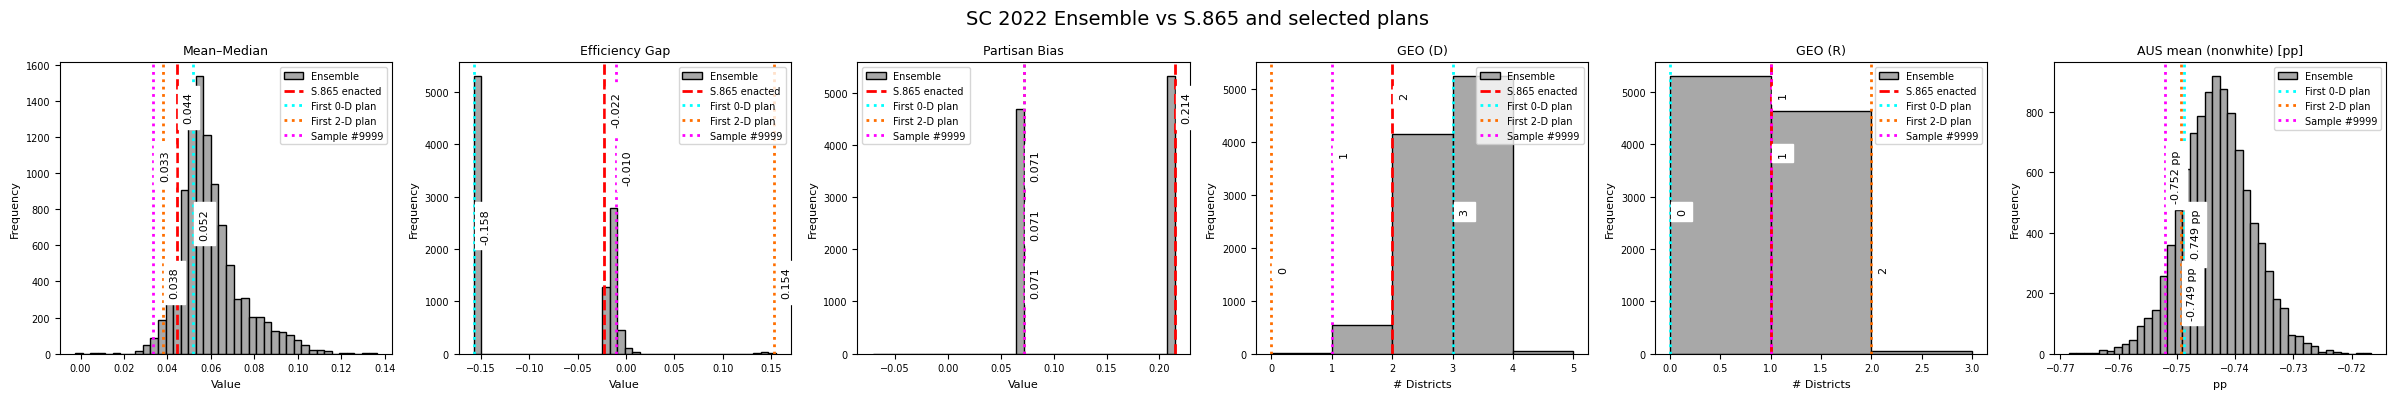

In [ ]:
# DeFord-style histograms for SC ensemble
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias

# Pick metrics_df 
metrics_df = None
for cand in ["df_extra", "df_out", "df"]:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame) and not globals()[cand].empty:
        metrics_df = globals()[cand].copy()
        print(f"Using metrics_df from: {cand} (cols={list(metrics_df.columns)[:12]} …)")
        break

if metrics_df is None:
    raise ValueError("No metrics dataframe found (df_extra / df_out / df). Run the SC chain first.")

if "step" not in metrics_df.columns:
    raise KeyError("metrics_df has no 'step' column; cannot find sampled plan.")

# Enacted SC plan partition 
if "part_s865" not in globals():
    raise KeyError("`part_s865` Partition (enacted S.865) not found. Build it before running this cell.")

part_enacted = part_s865

# Determine election alias
if "PRES20" in part_enacted.updaters:
    ELECTION_ALIAS = "PRES20"
elif "pres20" in part_enacted.updaters:
    ELECTION_ALIAS = "pres20"
else:
    raise KeyError("Neither 'PRES20' nor 'pres20' updater is present on `part_s865`.")

# Enacted/seed 
enacted_metrics = {}
try:
    enacted_metrics["mean_median"]    = float(mean_median(part_enacted[ELECTION_ALIAS]))
    enacted_metrics["efficiency_gap"] = float(efficiency_gap(part_enacted[ELECTION_ALIAS]))
    enacted_metrics["partisan_bias"]  = float(partisan_bias(part_enacted[ELECTION_ALIAS]))
except Exception as e:
    print("[warn] Could not compute enacted fairness metrics:", e)

if "geo_D" in part_enacted.updaters and "geo_R" in part_enacted.updaters:
    enacted_metrics["geo_D"] = int(part_enacted["geo_D"])
    enacted_metrics["geo_R"] = int(part_enacted["geo_R"])

# AUS 
aus_key = next((k for k in part_enacted.updaters.keys() if k.startswith("aus_")), None)
if aus_key is not None:
    try:
        seg0 = part_enacted[aus_key]   # {dist: {"S_pm": ..., ...}}
        svals0 = np.array([v["S_pm"] for v in seg0.values()], dtype=float)
        enacted_metrics[f"{aus_key}_n_packed"]  = int((svals0 > 0).sum())
        enacted_metrics[f"{aus_key}_n_cracked"] = int((svals0 < 0).sum())
        enacted_metrics[f"{aus_key}_mean_pp"]   = float(np.nanmean(svals0))
    except Exception as e:
        print(f"[warn] Could not compute enacted S± metrics from '{aus_key}':", e)

print("Enacted S.865 metrics (fairness trio + GEO if present):")
for k in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"]:
    if k in enacted_metrics:
        print(f"  {k}: {enacted_metrics[k]}")

# Normalize column names
col_aliases = {
    "mean_median":    ["mean_median", "meanmedian"],
    "efficiency_gap": ["efficiency_gap", "effgap"],
    "partisan_bias":  ["partisan_bias", "bias50"],
    "geo_D":          ["geo_D"],
    "geo_R":          ["geo_R"],
}
for canon, options in col_aliases.items():
    if canon not in metrics_df.columns:
        for opt in options:
            if opt in metrics_df.columns:
                metrics_df[canon] = metrics_df[opt]
                break

# AUS 
aus_mean_cols = [
    c for c in metrics_df.columns
    if c.endswith("_mean_pp") and c.startswith("aus_")
]

# AUS count + GEO integer metrics
int_metric_candidates = []
for c in metrics_df.columns:
    if c.startswith("aus_") and (c.endswith("_n_packed") or c.endswith("_n_cracked")):
        int_metric_candidates.append(c)
for c in ["geo_D", "geo_R"]:
    if c in metrics_df.columns and c not in int_metric_candidates:
        int_metric_candidates.append(c)

# Last-step sample metrics (9999)
SAMPLED_STEP = int(metrics_df["step"].max())
sample_row = metrics_df.loc[metrics_df["step"] == SAMPLED_STEP].iloc[0]

sample_metrics = {}
for m in metrics_df.columns:
    if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
       (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
        val = sample_row.get(m, np.nan)
        if pd.notna(val):
            sample_metrics[m] = float(val)

# First 0-seat and 2-seat plans 
metrics_0 = {}
metrics_2 = {}
seat_col = "dem20_seats" if "dem20_seats" in metrics_df.columns else None

row0 = None
row2 = None
if seat_col is not None:
    df_seats = metrics_df.dropna(subset=[seat_col])

    if (df_seats[seat_col] == 0).any():
        row0 = df_seats.loc[df_seats[seat_col] == 0].sort_values("step").iloc[0]
        print("First 0-seat plan at step:", int(row0["step"]))
    else:
        print("No 0-seat plan found in this chain.")

    if (df_seats[seat_col] == 2).any():
        row2 = df_seats.loc[df_seats[seat_col] == 2].sort_values("step").iloc[0]
        print("First 2-seat plan at step:", int(row2["step"]))
    else:
        print("No 2-seat plan found in this chain.")

    if row0 is not None:
        for m in metrics_df.columns:
            if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
               (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
                val = row0.get(m, np.nan)
                if pd.notna(val):
                    metrics_0[m] = float(val)

    if row2 is not None:
        for m in metrics_df.columns:
            if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
               (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
                val = row2.get(m, np.nan)
                if pd.notna(val):
                    metrics_2[m] = float(val)

# Decide which metrics to plot 
metrics_to_plot = []
for canon in ["mean_median", "efficiency_gap", "partisan_bias"]:
    if canon in metrics_df.columns:
        metrics_to_plot.append(canon)

for m in ["geo_D", "geo_R"]:
    if m in metrics_df.columns:
        metrics_to_plot.append(m)

for m in int_metric_candidates:
    if m in metrics_df.columns and m not in metrics_to_plot:
        metrics_to_plot.append(m)

metrics_to_plot.extend([m for m in aus_mean_cols if m not in metrics_to_plot])

if not metrics_to_plot:
    raise RuntimeError(
        "No metrics available to plot after normalization. "
        f"Columns are: {list(metrics_df.columns)}"
    )

# titles
pretty_map = {
    "geo_D": "GEO (D)",
    "geo_R": "GEO (R)",
    "mean_median": "Mean–Median",
    "efficiency_gap": "Efficiency Gap",
    "partisan_bias": "Partisan Bias",
}
for c in aus_mean_cols:
    group = c.replace("aus_", "").replace("_mean_pp", "")
    pretty_map[c] = f"AUS mean ({group}) [pp]"
for c in int_metric_candidates:
    if c not in pretty_map:
        if c.endswith("_n_packed"):
            pretty_map[c] = "S± packed (count)"
        elif c.endswith("_n_cracked"):
            pretty_map[c] = "S± cracked (count)"

# Multi-panel figure 
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 4))
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    if metric not in metrics_df.columns:
        ax.set_visible(False)
        continue

    series = metrics_df[metric].dropna()
    is_int_metric = metric in (["geo_D", "geo_R"] + int_metric_candidates)
    is_aus_mean   = metric in aus_mean_cols

    # Histogram bins
    if is_int_metric and len(series) > 0:
        lo, hi = int(series.min()), int(series.max())
        bins = np.arange(lo, hi + 2)
    else:
        bins = 40

    # Ensemble
    ax.hist(series, bins=bins, edgecolor="black", color="#A8A8A8", label="Ensemble")

    # S.865 
    if metric in enacted_metrics:
        val = enacted_metrics[metric]
        ax.axvline(val, color="red", linestyle="--", linewidth=2, label="S.865 enacted")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        offset = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(val):
            label_txt = f"{int(val)}"
        elif is_aus_mean and pd.notna(val):
            label_txt = f"{val:.3f} pp"
        else:
            label_txt = f"{val:.3f}" if pd.notna(val) else "n/a"
        ax.text(val + offset, ylim[1] * 0.9, label_txt,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    #  First 0-seat
    if metric in metrics_0:
        v0 = metrics_0[metric]
        ax.axvline(v0, color="cyan", linestyle=":", linewidth=2, label="First 0-D plan")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        off0 = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(v0):
            txt0 = f"{int(v0)}"
        elif is_aus_mean and pd.notna(v0):
            txt0 = f"{v0:.3f} pp"
        else:
            txt0 = f"{v0:.3f}" if pd.notna(v0) else "n/a"
        ax.text(v0 + off0, ylim[1] * 0.5, txt0,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # First 2-seat 
    if metric in metrics_2:
        v2 = metrics_2[metric]
        ax.axvline(v2, color="#FF6F00", linestyle=":", linewidth=2, label="First 2-D plan")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        off2 = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(v2):
            txt2 = f"{int(v2)}"
        elif is_aus_mean and pd.notna(v2):
            txt2 = f"{v2:.3f} pp"
        else:
            txt2 = f"{v2:.3f}" if pd.notna(v2) else "n/a"
        ax.text(v2 + off2, ylim[1] * 0.3, txt2,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # Last sample (9999) 
    if metric in sample_metrics:
        sval = sample_metrics[metric]
        ax.axvline(sval, color="magenta", linestyle=":", linewidth=2,
                   label=f"Sample #{SAMPLED_STEP}")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        soffset = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(sval):
            slabel_txt = f"{int(sval)}"
        elif is_aus_mean and pd.notna(sval):
            slabel_txt = f"{sval:.3f} pp"
        else:
            slabel_txt = f"{sval:.3f}" if pd.notna(sval) else "n/a"
        ax.text(sval + soffset, ylim[1] * 0.7, slabel_txt,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    pretty_name = pretty_map.get(metric, metric.replace("_", " ").title())
    ax.set_title(pretty_name)
    ax.set_xlabel("# Districts" if is_int_metric else ("pp" if is_aus_mean else "Value"))
    ax.set_ylabel("Frequency")
    ax.legend(loc="best")

plt.suptitle("SC 2022 Ensemble vs S.865 and selected plans", fontsize=14)
out_root = Path("./outputs/SC22")
out_root.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(out_root / "sc22_ensemble_histograms_with_enacted_and_samples.png", dpi=200)
print("Saved:", out_root / "sc22_ensemble_histograms_with_enacted_and_samples.png")
plt.show()


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
C:\Users\kubak\AppData\Local\Temp\ipykernel_25296\4009845163.py:226: UserW


=== SC 2022 – Enacted plan, selected Runs, and ensemble mean ===
            Label  Run  cut_edges  dem_seats  max_pop_dev_pct
    Enacted S.865  N/A   474.0000     1.0000         0.573751
First 0-seat plan    0   553.0000     0.0000         0.745797
First 2-seat plan  341   419.0000     2.0000         0.675697
     Sample #9999 9999   392.0000     1.0000         0.873864
    Ensemble mean  All   421.1441     0.4748         0.865837
Saved diagnostics to: outputs\SC22\sc22_chain_diagnostics_S865_0_2_9999.png


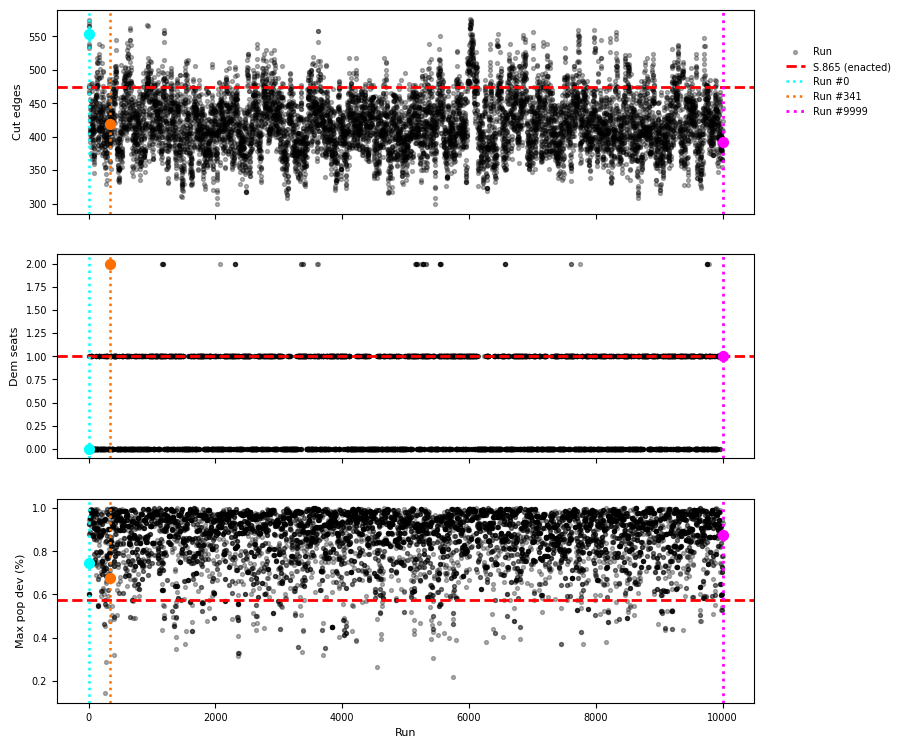

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# column names
seat_col = "dem20_seats"           # SC chain seats column
col_dev  = "max_abs_pop_dev_pct"   # population deviation column

# metrics_df must already exist 
assert "metrics_df" in globals(), "`metrics_df` must exist (from SC chain summary)."
assert "part_s865" in globals(), "`part_s865` (enacted S.865 Partition) must exist."


# Enacted metrics 
enacted_cut_edges = len(part_s865["cut_edges"])
enacted_seats     = int(part_s865["PRES20"].seats("D"))

pop_by_dist = pd.Series(part_s865["population"], dtype=float)
ideal_pop   = pop_by_dist.mean()
enacted_pop_dev = float(((pop_by_dist - ideal_pop) / ideal_pop).abs().max() * 100)


# Sample 9999

TARGET_SAMPLE_STEP = 9999
if TARGET_SAMPLE_STEP not in metrics_df["step"].values:
    raise ValueError(f"Step {TARGET_SAMPLE_STEP} not found in metrics_df['step'].")

row_sample       = metrics_df.loc[metrics_df["step"] == TARGET_SAMPLE_STEP].iloc[0]
sample_step      = int(row_sample["step"])
sample_cut_edges = float(row_sample["cut_edges"])
sample_seats     = int(row_sample[seat_col])
sample_pop_dev   = float(row_sample[col_dev])


# First 0-seat and 2-seat 
row0 = None
row2 = None

if seat_col in metrics_df.columns:
    df_seats = metrics_df.dropna(subset=[seat_col])

    # first plan with 0 D seats
    if (df_seats[seat_col] == 0).any():
        row0 = df_seats.loc[df_seats[seat_col] == 0].sort_values("step").iloc[0]

    # first plan with 2 D seats
    if (df_seats[seat_col] == 2).any():
        row2 = df_seats.loc[df_seats[seat_col] == 2].sort_values("step").iloc[0]


# Ensemble means
ens_cut_edges_mean = float(metrics_df["cut_edges"].mean())
ens_seats_mean     = float(metrics_df[seat_col].mean())
ens_pop_dev_mean   = float(metrics_df[col_dev].mean())

# summary table

print("\n=== SC 2022 – Enacted plan, selected Runs, and ensemble mean ===")
summary_rows = []

# Enacted
summary_rows.append({
    "Label": "Enacted S.865",
    "Run": "N/A",
    "cut_edges": enacted_cut_edges,
    "dem_seats": enacted_seats,
    "max_pop_dev_pct": enacted_pop_dev,
})

# First 0-seat plan
if row0 is not None:
    summary_rows.append({
        "Label": "First 0-seat plan",
        "Run": int(row0["step"]),
        "cut_edges": float(row0["cut_edges"]),
        "dem_seats": int(row0[seat_col]),
        "max_pop_dev_pct": float(row0[col_dev]),
    })
else:
    print("No 0-seat plan found in the chain.")

# First 2-seat plan
if row2 is not None:
    summary_rows.append({
        "Label": "First 2-seat plan",
        "Run": int(row2["step"]),
        "cut_edges": float(row2["cut_edges"]),
        "dem_seats": int(row2[seat_col]),
        "max_pop_dev_pct": float(row2[col_dev]),
    })
else:
    print("No 2-seat plan found in the chain.")

# Sample 9999
summary_rows.append({
    "Label": "Sample #9999",
    "Run": sample_step,
    "cut_edges": sample_cut_edges,
    "dem_seats": sample_seats,
    "max_pop_dev_pct": sample_pop_dev,
})

# Ensemble mean
summary_rows.append({
    "Label": "Ensemble mean",
    "Run": "All",
    "cut_edges": ens_cut_edges_mean,
    "dem_seats": ens_seats_mean,
    "max_pop_dev_pct": ens_pop_dev_mean,
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


# Plot diagnostics
fig, axs = plt.subplots(3, 1, figsize=(9, 9), sharex=True)


# Cut edges
axs[0].scatter(
    metrics_df["step"], metrics_df["cut_edges"],
    s=8, alpha=0.3, color="black", label="Run"
)

# Enacted S.865
axs[0].axhline(
    enacted_cut_edges, color="red", linestyle="--", lw=2,
    label="S.865 (enacted)"
)

# First 0-seat plan
if row0 is not None:
    axs[0].axvline(
        row0["step"], color="cyan", linestyle=":", lw=1.8,
        label=f"Run #{int(row0['step'])}"
    )
    axs[0].scatter(row0["step"], row0["cut_edges"], color="cyan", s=50, zorder=6)

# First 2-seat plan
if row2 is not None:
    axs[0].axvline(
        row2["step"], color="#FF6F00", linestyle=":", lw=1.8,
        label=f"Run #{int(row2['step'])}"
    )
    axs[0].scatter(row2["step"], row2["cut_edges"], color="#FF6F00", s=50, zorder=6)

# Sample step 9999
axs[0].axvline(
    sample_step, color="magenta", linestyle=":", lw=2,
    label=f"Run #{sample_step}"
)
axs[0].scatter(sample_step, sample_cut_edges, color="magenta", s=50, zorder=5)

axs[0].set_ylabel("Cut edges")


# Democratic seats

axs[1].scatter(
    metrics_df["step"], metrics_df[seat_col],
    s=8, alpha=0.3, color="black"
)

axs[1].axhline(enacted_seats, color="red", linestyle="--", lw=2)

axs[1].axvline(sample_step, color="magenta", linestyle=":", lw=2)
axs[1].scatter(sample_step, sample_seats, color="magenta", s=50, zorder=5)

if row0 is not None:
    axs[1].axvline(row0["step"], color="cyan", linestyle=":", lw=1.8)
    axs[1].scatter(row0["step"], row0[seat_col], color="cyan", s=50, zorder=6)

if row2 is not None:
    axs[1].axvline(row2["step"], color="#FF6F00", linestyle=":", lw=1.8)
    axs[1].scatter(row2["step"], row2[seat_col], color="#FF6F00", s=50, zorder=6)

axs[1].set_ylabel("Dem seats")


# Population deviation
axs[2].scatter(
    metrics_df["step"], metrics_df[col_dev],
    s=8, alpha=0.3, color="black"
)

axs[2].axhline(enacted_pop_dev, color="red", linestyle="--", lw=2)
axs[2].axvline(sample_step, color="magenta", linestyle=":", lw=2)
axs[2].scatter(sample_step, sample_pop_dev, color="magenta", s=50, zorder=5)

if row0 is not None:
    axs[2].axvline(row0["step"], color="cyan", linestyle=":", lw=1.8)
    axs[2].scatter(row0["step"], row0[col_dev], color="cyan", s=50, zorder=6)

if row2 is not None:
    axs[2].axvline(row2["step"], color="#FF6F00", linestyle=":", lw=1.8)
    axs[2].scatter(row2["step"], row2[col_dev], color="#FF6F00", s=50, zorder=6)

axs[2].set_ylabel("Max pop dev (%)")
axs[2].set_xlabel("Run")

# Single legend 
handles, labels = axs[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove duplicates

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="center left",
    bbox_to_anchor=(0.925, 0.8),
    frameon=False
)

plt.tight_layout(rect=[0.0, 0.0, 0.0, 0.0])

out_diag = Path("./outputs/SC22/sc22_chain_diagnostics_S865_0_2_9999.png")
out_diag.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_diag, dpi=200)
print("Saved diagnostics to:", out_diag)
plt.show()


Using metrics from: df_extra (rows=10000)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/SC22/sc_2022_sc_2022_sample_plan_0D_vote_shares.png


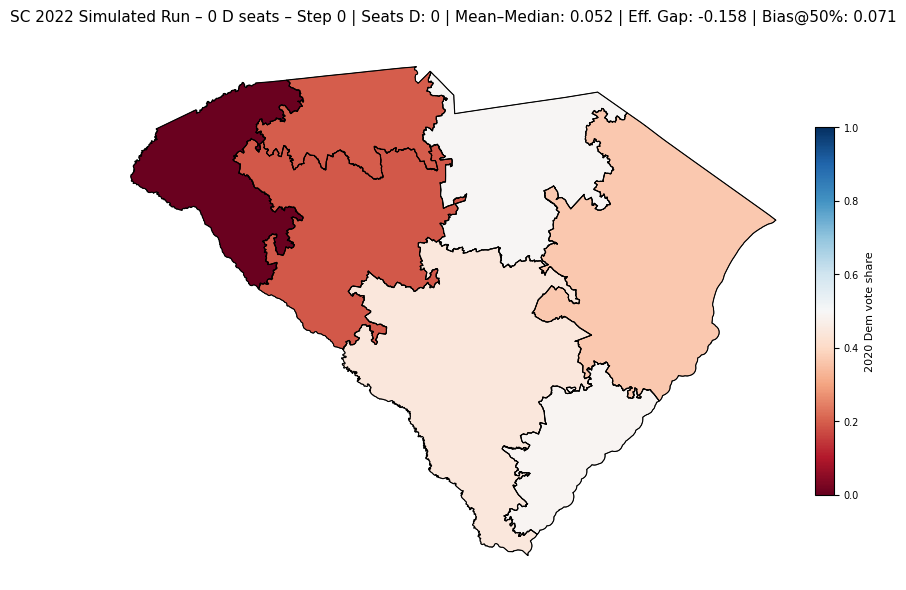

Using metrics from: df_extra (rows=10000)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/SC22/sc_2022_sc_2022_sample_plan_2D_vote_shares.png


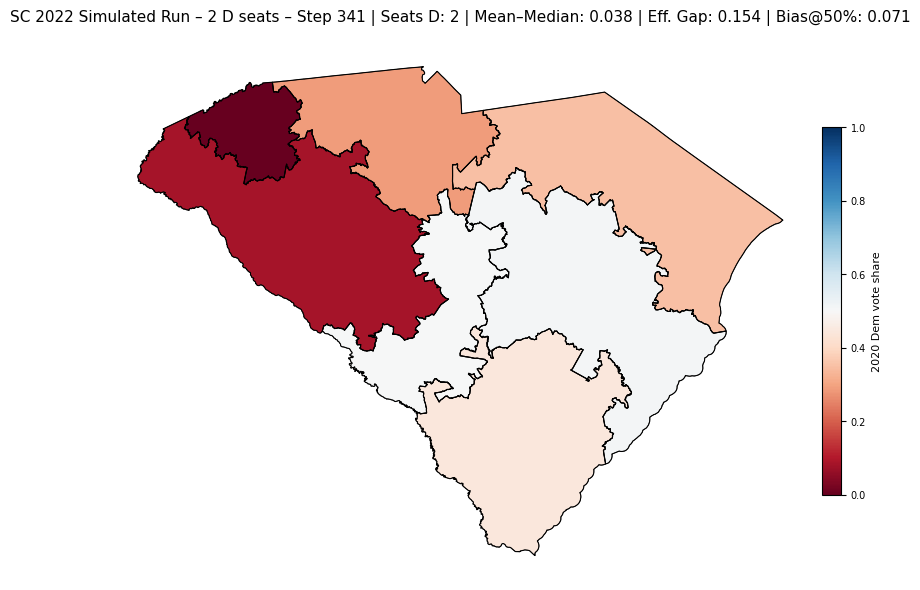

Using metrics from: df_extra (rows=10000)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/SC22/sc_2022_sc_2022_sample_plan_step9999_vote_shares.png


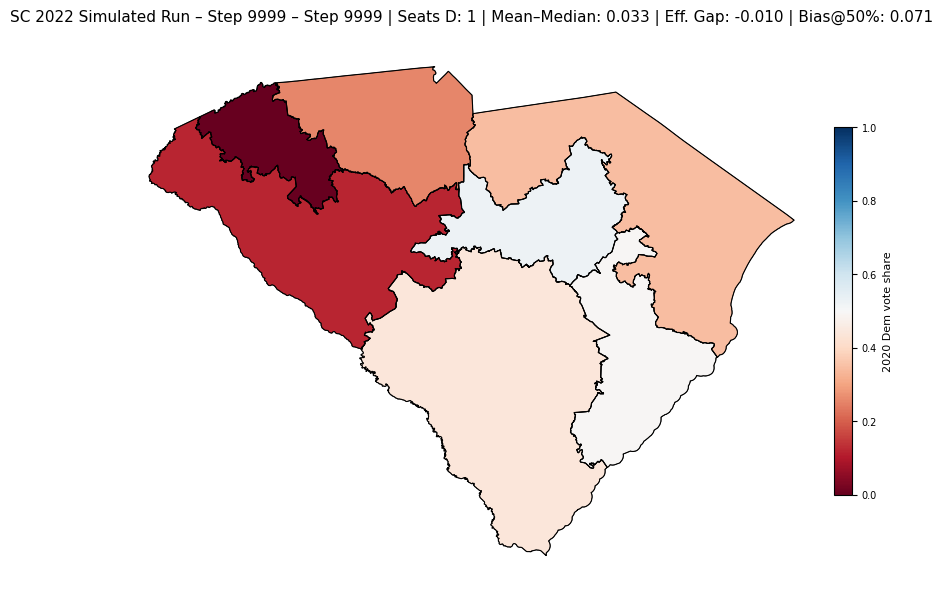

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path


# funcs
def _choose_metrics_df(globs):
    want_any = [
        {"dem20_seats", "dem_seats"},
        {"meanmedian", "mean_median"},
        {"effgap", "efficiency_gap"},
        {"bias50", "partisan_bias"},
        {"step"},
    ]
    def has_any(df):
        cols = set(df.columns)
        return all(len(cols & opt) > 0 for opt in want_any)

    candidates = []
    for name in ["df_extra", "df_out", "df"]:
        if name in globs and isinstance(globs[name], pd.DataFrame) and not globs[name].empty:
            candidates.append((name, globs[name]))
    if not candidates:
        raise ValueError("No metrics dataframe found (df_extra / df_out / df). Run the SC chain first.")
    best = next(((n, d) for n, d in candidates if has_any(d)), None)
    if best is None:
        best = max(candidates, key=lambda nd: nd[1]["step"].max() if "step" in nd[1] else -1)
    print(f"Using metrics from: {best[0]} (rows={len(best[1])})")
    return best[1]


def _get(m, keys, default=np.nan):
    for k in keys:
        if k in m:
            return m[k]
    return default


def _ensure_votes_on_plan(plan, gdf):
    """Ensure PRES20D/PRES20R are present on the district plan by aggregating VTD votes if needed."""
    need_cols = {"PRES20D", "PRES20R"}
    if need_cols.issubset(plan.columns):
        return plan

    if gdf is None or not isinstance(gdf, gpd.GeoDataFrame):
        raise KeyError(
            "`plan` is missing PRES20D/PRES20R and `gdf` is not available "
            "to rebuild them. Please keep `gdf` (SC VTDs) in memory."
        )
    if not {"PRES20D", "PRES20R"}.issubset(gdf.columns):
        raise KeyError("`gdf` lacks PRES20D/PRES20R; attach votes to VTDs before plotting.")

    gdf2 = gdf.copy()
    if plan.crs is None:
        raise ValueError("`plan` has no CRS; set a CRS before spatial join.")
    if gdf2.crs != plan.crs:
        gdf2 = gdf2.to_crs(plan.crs)

    # point-in-polygon tag: VTD -> district
    pts = gdf2.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(
        gdf2[["PRES20D", "PRES20R"]].copy(), geometry=pts, crs=gdf2.crs
    )
    tag = gpd.sjoin(
        pts_gdf, plan[["district", "geometry"]],
        predicate="within", how="left"
    )
    grp = tag.groupby("district")[["PRES20D", "PRES20R"]].sum().reset_index()
    plan = plan.merge(grp, on="district", how="left")
    return plan


def _plot_plan(plan, metrics_row, title_prefix, out_name):
    """Generic plotting helper for one SC plan."""
    fig, ax = plt.subplots(figsize=(8, 8))
    vmin, vmax = 0.0, 1.0
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.RdBu  # 0=red (R), 1=blue (D)

    # borders 
    plan.boundary.plot(ax=ax, linewidth=0.8, edgecolor="black")
    plan.plot(
        column="dist_dem20_share",
        cmap=cmap,
        norm=norm,
        linewidth=0.4,
        edgecolor="black",
        ax=ax,
    )

    # colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("2020 Dem vote share")

    # title
    seats_D     = _get(metrics_row, ["dem20_seats", "dem_seats"])
    mean_median = _get(metrics_row, ["meanmedian", "mean_median"])
    eff_gap     = _get(metrics_row, ["effgap", "efficiency_gap"])
    bias50      = _get(metrics_row, ["bias50", "partisan_bias"])
    step        = int(metrics_row["step"]) if "step" in metrics_row else None

    title_lines = [
        f"{title_prefix} – Step {step}" if step is not None else title_prefix,
        f"Seats D: {int(seats_D) if pd.notna(seats_D) else 'n/a'}",
        f"Mean–Median: {mean_median:.3f}" if pd.notna(mean_median) else "Mean–Median: n/a",
        f"Eff. Gap: {eff_gap:.3f}" if pd.notna(eff_gap) else "Eff. Gap: n/a",
        f"Bias@50%: {bias50:.3f}" if pd.notna(bias50) else "Bias@50%: n/a",
    ]
    ax.set_title(" | ".join(title_lines), fontsize=11)
    ax.set_axis_off()
    plt.tight_layout()

    out_dir = Path("./outputs/SC22")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_dir / out_name
    plt.savefig(out_png.as_posix(), dpi=200)
    print("Saved figure to:", out_png.as_posix())
    plt.show()


def plot_saved_plan(plan_path_str, label_prefix):
    """Load a saved SC GPKG, match its step to metrics_df, and plot."""
    metrics_df = _choose_metrics_df(globals())

    plan_path = Path(plan_path_str)
    if not plan_path.exists():
        raise FileNotFoundError(f"Plan file not found: {plan_path}")

    plan = gpd.read_file(plan_path, engine="pyogrio")

    # ensure district column
    if "district" not in plan.columns:
        for alt in ["DISTRICT", "district_id", "DistID", "CD", "CONG_DIST"]:
            if alt in plan.columns:
                plan = plan.rename(columns={alt: "district"})
                break
    if "district" not in plan.columns:
        raise KeyError("`plan` is missing a 'district' field.")

    # find step
    if "step" in plan.columns and "step" in metrics_df.columns:
        step_for_plan = int(plan["step"].iloc[0])
        if step_for_plan not in metrics_df["step"].values:
            raise ValueError(f"Step {step_for_plan} from plan file not in metrics_df.")
        metrics_row = metrics_df.loc[metrics_df["step"] == step_for_plan].iloc[0]
    else:
        # fallback by filename + seat count (0D / 2D / step9999)
        seat_col = "dem20_seats" if "dem20_seats" in metrics_df.columns else "dem_seats"
        stem = plan_path.stem.lower()

        if "0d" in stem:
            target_seats = 0
            subset = metrics_df.loc[metrics_df[seat_col] == target_seats]
        elif "2d" in stem:
            target_seats = 2
            subset = metrics_df.loc[metrics_df[seat_col] == target_seats]
        elif "9999" in stem and "step" in metrics_df.columns:
            subset = metrics_df.loc[metrics_df["step"] == 9999]
        else:
            raise ValueError("Plan has no 'step' column and filename doesn't encode seats/step.")

        if subset.empty:
            raise ValueError("No matching row in metrics_df for this plan.")
        metrics_row = subset.sort_values("step").iloc[0]

    # ensure votes on plan
    gdf = globals().get("gdf", None)
    plan = _ensure_votes_on_plan(plan, gdf)

    # compute party share
    if "dist_dem20_share" not in plan.columns:
        two_party = (plan["PRES20D"] + plan["PRES20R"]).replace(0, np.nan)
        plan["dist_dem20_share"] = plan["PRES20D"] / two_party

    # output 
    out_name = f"sc_2022_{plan_path.stem}_vote_shares.png"
    _plot_plan(plan, metrics_row, title_prefix=label_prefix, out_name=out_name)


#  0-seat, 2-seat, and 9999 
plot_saved_plan(
    "./outputs/SC22/sc_2022_sample_plan_0D.gpkg",
    label_prefix="SC 2022 Simulated Run – 0 D seats"
)

plot_saved_plan(
    "./outputs/SC22/sc_2022_sample_plan_2D.gpkg",
    label_prefix="SC 2022 Simulated Run – 2 D seats"
)

plot_saved_plan(
    "./outputs/SC22/sc_2022_sample_plan_step9999.gpkg",
    label_prefix="SC 2022 Simulated Run – Step 9999"
)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


[warn] 20 VTDs did not fall within any S.865 precinct; dropping them for the map.
SC 2022 enacted S.865 (reconstructed on VTD grid):
  Seats D: 1
  Mean Dem share: 0.30788784882347076
  Mean–Median: -0.04860843406239651
Saved figure to: outputs/SC22/sc_2022_enacted_S865_vote_shares_reconstructed.png


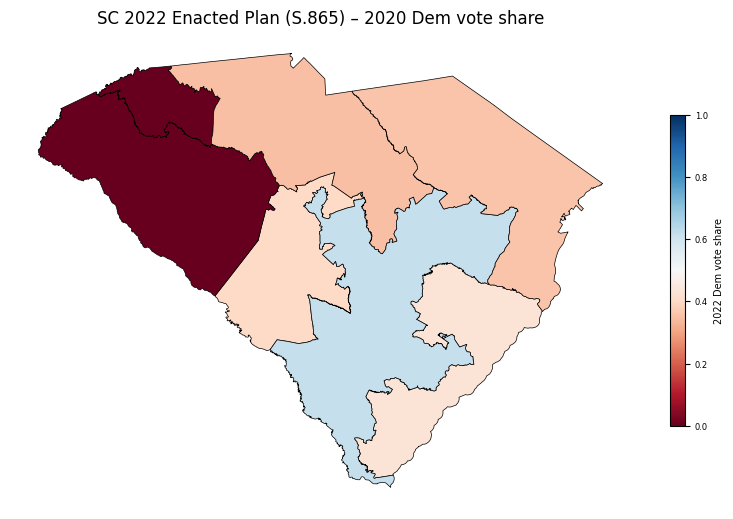

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import pandas as pd
import numpy as np
import re
from pathlib import Path


# Preconditions

assert "gdf" in globals(), "`gdf` (SC VTD GeoDataFrame) must exist (same one used in the chain)."
if not {"PRES20D", "PRES20R"}.issubset(gdf.columns):
    raise KeyError("`gdf` must contain PRES20D and PRES20R (the two-party vote fields).")

vtd_crs = gdf.crs

# ---------------------------------------------------
# 1) Load S.865 precinct layer only to get district labels
# ---------------------------------------------------
prec_path = Path("./inputs/SC/sc_2022_gen_prec/sc_2022_gen_cong_prec/sc_2022_gen_cong_prec.shp")
if not prec_path.exists():
    raise FileNotFoundError(f"Cannot find SC 2022 precinct file at: {prec_path}")

vest = gpd.read_file(prec_path, engine="pyogrio")

# Standardize district column
if "district" not in vest.columns:
    for alt in ["CONG_DIST", "DISTRICT", "CD", "USCD", "CDIST"]:
        if alt in vest.columns:
            vest = vest.rename(columns={alt: "district"})
            break
if "district" not in vest.columns:
    raise KeyError("Precinct file has no recognizable congressional district column.")

# Normalize district labels like '1','2',...,'7'
vest["district"] = (
    vest["district"]
    .astype(str)
    .str.strip()
    .str.extract(r"(\d+)", expand=False)
    .str.lstrip("0")
)

# ---------------------------------------------------
# 2) CRS harmonization – keep VTD CRS, move precincts to it
# ---------------------------------------------------
if vest.crs is None:
    raise ValueError("Precinct file has no CRS; set it before running.")

if vest.crs != vtd_crs:
    vest = vest.to_crs(vtd_crs)

gdf2 = gdf.copy()   # stays in vtd_crs

# Representative points for VTDs
pts = gdf2.geometry.representative_point()
pts_gdf = gpd.GeoDataFrame(
    gdf2[["PRES20D", "PRES20R"]].copy(),  # payload irrelevant; index + geometry matter
    geometry=pts,
    crs=vtd_crs,
)

# Spatial join: VTD point -> S.865 district
tag = gpd.sjoin(
    pts_gdf,
    vest[["district", "geometry"]],
    predicate="within",
    how="left",
)

# Attach district label back to gdf2
gdf2["district_s865"] = tag["district"]

n_na = int(gdf2["district_s865"].isna().sum())
if n_na > 0:
    print(f"[warn] {n_na} VTDs did not fall within any S.865 precinct; dropping them for the map.")
    gdf2 = gdf2.loc[gdf2["district_s865"].notna()].copy()

# ---------------------------------------------------
# 3) Dissolve VTDs by S.865 district → clean district geometry
#     (still in the same CRS as the simulated plans)
# ---------------------------------------------------
geom_by_dist = (
    gdf2[["district_s865", "geometry"]]
    .dissolve(by="district_s865")
    .reset_index()
    .rename(columns={"district_s865": "district"})
)

votes_by_dist = (
    gdf2
    .groupby("district_s865")[["PRES20D", "PRES20R"]]
    .sum()
    .reset_index()
    .rename(columns={"district_s865": "district"})
)

plan = geom_by_dist.merge(votes_by_dist, on="district", how="left")

# ---------------------------------------------------
# 4) Compute 2020 Dem two-party share + basic metrics
# ---------------------------------------------------
two_party = (plan["PRES20D"] + plan["PRES20R"]).replace(0, np.nan)
plan["dist_dem20_share"] = plan["PRES20D"] / two_party

dem = plan["PRES20D"].astype(float)
rep = plan["PRES20R"].astype(float)
two = dem + rep
share_D = dem / two.replace(0, np.nan)

enacted_seats_D        = int((dem > rep).sum())
enacted_mean_dem_share = float(share_D.mean(skipna=True))
enacted_meanmedian     = float(share_D.mean(skipna=True) - share_D.median(skipna=True))

print("SC 2022 enacted S.865 (reconstructed on VTD grid):")
print("  Seats D:", enacted_seats_D)
print("  Mean Dem share:", enacted_mean_dem_share)
print("  Mean–Median:", enacted_meanmedian)

# ---------------------------------------------------
# 5) Plot (Texas-style, in the SAME CRS as the simulated plans)
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = 0.0, 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdBu  # 0 = red (R), 1 = blue (D)

plan.plot(
    column="dist_dem20_share",
    ax=ax,
    cmap=cmap,
    linewidth=0.5,
    edgecolor="black",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={
        "label": "",
        "shrink": 0.40,   # shrink colorbar height
    },
)

# --- shrink + restyle colorbar (like TX AUS map) ---
cbar_ax = ax.get_figure().axes[-1]      # colorbar axis
box = cbar_ax.get_position()

cbar_ax.set_position([
    box.x0 + 0.01,        # small shift to the right
    box.y0,
    box.width * 0.50,     # half the original width
    box.height,
])

cbar_ax.tick_params(labelsize=6)
cbar_ax.set_ylabel("2022 Dem vote share", fontsize=7)

ax.set_title(
    "SC 2022 Enacted Plan (S.865) – 2020 Dem vote share",
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()

out_dir = Path("./outputs/SC22")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "sc_2022_enacted_S865_vote_shares_reconstructed.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved figure to:", out_png.as_posix())
plt.show()


SC 2022 enacted S.865:
  Seats D: 1
  Mean Dem share: 0.2661520695086839
  Mean–Median: -0.08009490385693352
Saved figure to: outputs/SC22/sc_2022_enacted_S865_vote_shares.png


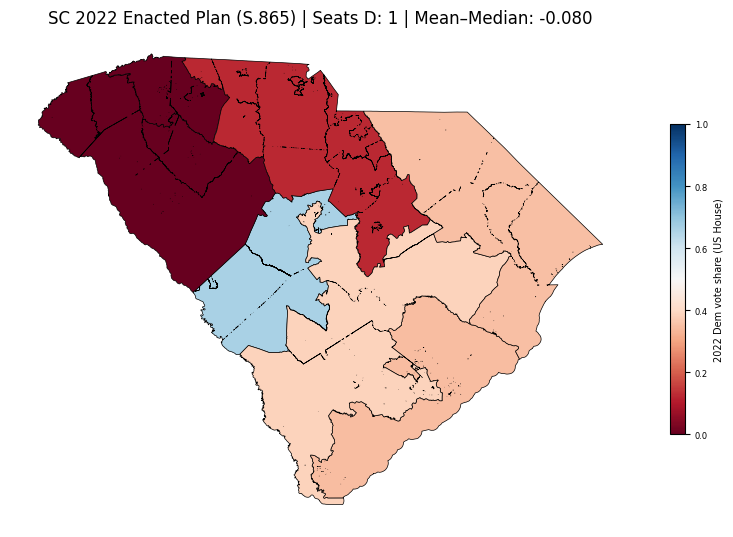

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import pandas as pd
import numpy as np
import re
from pathlib import Path

# ---- 1) Load SC 2022 precincts with congressional districts ----
sc_path = Path("./inputs/SC/sc_2022_gen_prec/sc_2022_gen_cong_prec/sc_2022_gen_cong_prec.shp")
if not sc_path.exists():
    raise FileNotFoundError(f"Cannot find SC 2022 precinct file at: {sc_path}")

vest = gpd.read_file(sc_path, engine="pyogrio")

# ---- 2) Standardize district column name -> 'district' ----
if "district" not in vest.columns:
    for alt in ["CONG_DIST", "DISTRICT", "CD", "USCD", "CDIST"]:
        if alt in vest.columns:
            vest = vest.rename(columns={alt: "district"})
            break

if "district" not in vest.columns:
    raise KeyError("Precinct file has no recognizable congressional district column.")

# Make districts simple strings like '1','2',...,'7'
vest["district"] = vest["district"].astype(str).str.lstrip("0")

# ---- 3) Find 2022 US House Dem/Rep/Other columns and build totals ----
dem_cols = [c for c in vest.columns if re.fullmatch(r"GCON\d{2}D.*", c)]
rep_cols = [c for c in vest.columns if re.fullmatch(r"GCON\d{2}R.*", c)]
oth_cols = [c for c in vest.columns if re.fullmatch(r"GCON\d{2}OWRI", c)]

if not dem_cols or not rep_cols:
    raise KeyError(
        "Could not find GCONxxD*/GCONxxR* columns for SC 2022 US House in precinct file.\n"
        f"Dem-like: {dem_cols}\nRep-like: {rep_cols}"
    )

for c in dem_cols + rep_cols + oth_cols:
    vest[c] = pd.to_numeric(vest[c], errors="coerce").fillna(0.0)

vest["PRES20D"]   = vest[dem_cols].sum(axis=1)
vest["PRES20R"]   = vest[rep_cols].sum(axis=1)
vest["PRES20OTH"] = vest[oth_cols].sum(axis=1) if oth_cols else 0.0
vest["TOTTO20"]   = vest["PRES20D"] + vest["PRES20R"] + vest["PRES20OTH"]

# ---- 4) Dissolve precincts → congressional districts (like TX district layer) ----
plan = vest.dissolve(by="district", as_index=False)

# ---- 5) Compute Dem two-party share per district ----
two_party = (plan["PRES20D"] + plan["PRES20R"]).replace(0, np.nan)
plan["dist_dem20_share"] = plan["PRES20D"] / two_party

dem = plan["PRES20D"].astype(float)
rep = plan["PRES20R"].astype(float)
two = dem + rep
share_D = dem / two.replace(0, np.nan)

enacted_seats_D        = int((dem > rep).sum())
enacted_mean_dem_share = float(share_D.mean(skipna=True))
enacted_meanmedian     = float(share_D.mean(skipna=True) - share_D.median(skipna=True))

print("SC 2022 enacted S.865:")
print("  Seats D:", enacted_seats_D)
print("  Mean Dem share:", enacted_mean_dem_share)
print("  Mean–Median:", enacted_meanmedian)

# ---- 6) Plot: district choropleth (Texas AUS style) ----
fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = 0.0, 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdBu  # 0 = red (R), 1 = blue (D)

plan.plot(
    column="dist_dem20_share",
    ax=ax,
    cmap=cmap,
    linewidth=0.5,
    edgecolor="black",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={
        "label": "",
        "shrink": 0.40,   # shrink colorbar height
    },
)

# ---- 7) Shrink + restyle colorbar (same pattern as TX AUS cell) ----
cbar_ax = ax.get_figure().axes[-1]   # colorbar axis
box = cbar_ax.get_position()
cbar_ax.set_position([
    box.x0 + 0.01,        # slight shift right
    box.y0,
    box.width * 0.50,     # half original width
    box.height,
])
cbar_ax.tick_params(labelsize=6)
cbar_ax.set_ylabel("2022 Dem vote share (US House)", fontsize=7)

# ---- 8) Title & layout (no district labels) ----
title_lines = [
    "SC 2022 Enacted Plan (S.865)",
    f"Seats D: {enacted_seats_D}",
    f"Mean–Median: {enacted_meanmedian:.3f}",
]
ax.set_title(" | ".join(title_lines), fontsize=12)
ax.set_axis_off()
plt.tight_layout()

out_dir = Path("./outputs/SC22")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "sc_2022_enacted_S865_vote_shares.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved figure to:", out_png.as_posix())
plt.show()


Using AUS updater: aus_nonwhite
Head of enacted AUS table (district-level, VTD-based geometry):
  district  aus_nonwhite_S_pm
0        1          -6.424704
1        2          -5.227278
2        3          -3.194570
3        4           2.728248
4        5          -3.974751
Saved AUS choropleth to: outputs/SC22/sc_2022_enacted_S865_aus_Spm_choropleth_vtdgeom.png


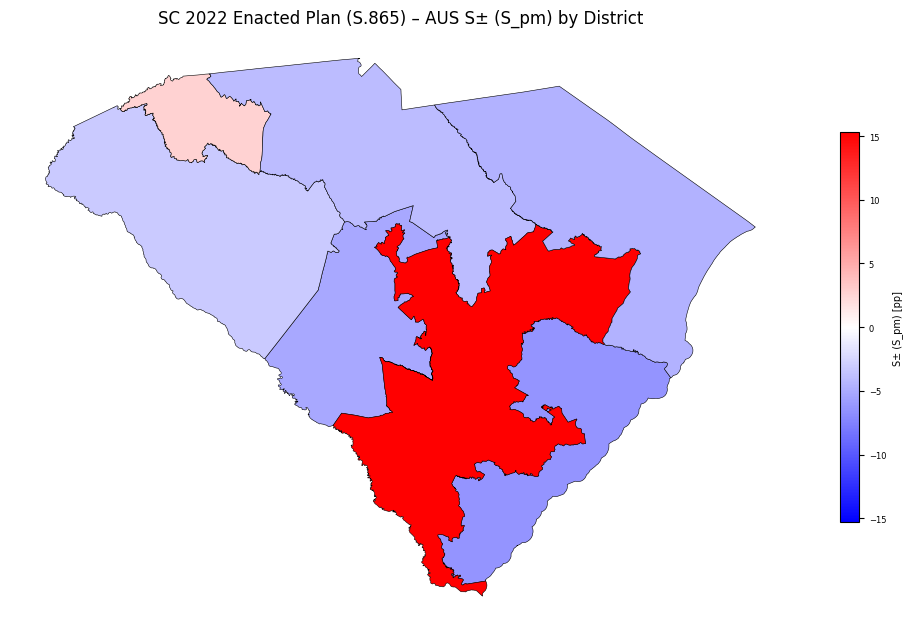

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path

# sanity checks 
assert "gdf" in globals(), "`gdf` (VTD GeoDataFrame) must exist."
assert "part_s865" in globals(), "`part_s865` (enacted S.865 Partition) must exist."
assert "my_updaters" in globals(), "`my_updaters` (with AUS) must exist."

# find AUS updater 
aus_key = next((k for k in my_updaters.keys() if k.startswith("aus_")), None)
if aus_key is None:
    raise KeyError("No AUS updater found in my_updaters (no key starting with 'aus_').")
print("Using AUS updater:", aus_key)

# Build district-level geometry from VTDs 
assign_series = pd.Series(part_s865.assignment, name="district").reindex(gdf.index)

if assign_series.isna().any():
    n_na = int(assign_series.isna().sum())
    raise ValueError(
        f"{n_na} VTDs in gdf have no S.865 district in part_s865.assignment. "
        "Fix the assignment before mapping AUS."
    )

gdf_plan = gdf.copy()
gdf_plan["district"] = assign_series.astype(str)

# Dissolve VTDs by district 
plan = (
    gdf_plan[["district", "geometry"]]
    .dissolve(by="district", as_index=False)
    .set_geometry("geometry")
)

# Pull AUS 
aus_dict = part_s865[aus_key] 

# normalize keys 
aus_S_pm = {str(d): vals.get("S_pm", np.nan) for d, vals in aus_dict.items()}
aus_Spm_col = f"{aus_key}_S_pm"   # e.g. 'aus_BLACK_S_pm'

plan[aus_Spm_col] = plan["district"].map(aus_S_pm)

print("Head of enacted AUS table (district-level, VTD-based geometry):")
print(plan[["district", aus_Spm_col]].head())

# Choropleth on S.865 districts 
vmax = float(np.nanmax(np.abs(plan[aus_Spm_col])))
if vmax == 0:
    vmax = 1.0
vmin = -vmax

fig, ax = plt.subplots(figsize=(10, 10))

plan.plot(
    column=aus_Spm_col,
    cmap="bwr",
    linewidth=0.4,
    edgecolor="black",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={
        "label": "",
        "shrink": 0.40,
    },
    ax=ax,
)

#  shrink + restyle colorbar 
cbar_ax = ax.get_figure().axes[-1]   # colorbar axis
box = cbar_ax.get_position()

# Make colorbar narrower & shift right slightly
cbar_ax.set_position([
    box.x0 + 0.01,
    box.y0,
    box.width * 0.50,
    box.height,
])

# Smaller ticks + label
cbar_ax.tick_params(labelsize=6)
cbar_ax.set_ylabel("S± (S_pm) [pp]", fontsize=7)


ax.set_title("SC 2022 Enacted Plan (S.865) – AUS S\u00b1 (S_pm) by District", fontsize=12)
ax.set_axis_off()
plt.tight_layout()

out_dir = Path("./outputs/SC22")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "sc_2022_enacted_S865_aus_Spm_choropleth_vtdgeom.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved AUS choropleth to:", out_png.as_posix())
plt.show()


Using AUS column: aus_nonwhite_S_pm
Saved AUS choropleth to: outputs/SC22/sc_2022_sample_step9999_aus_Spm_choropleth.png


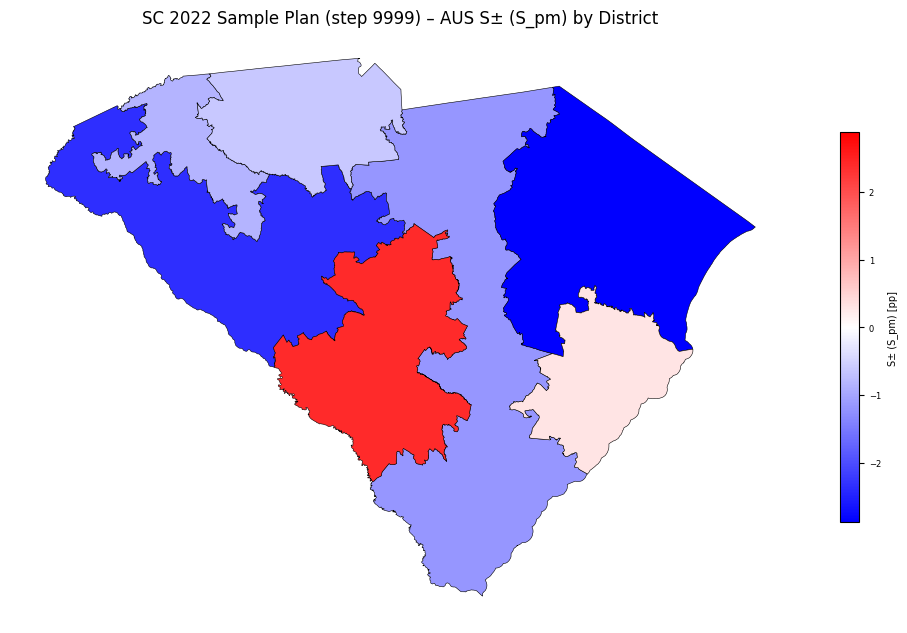

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from pathlib import Path

# Load step 9999
plan_path = Path("./outputs/SC22/sc_2022_sample_plan_with_aus_fairness.gpkg")
if not plan_path.exists():
    raise FileNotFoundError(f"Sample AUS plan not found at {plan_path}")

try:
    plan = gpd.read_file(plan_path, layer="districts", engine="pyogrio")
except Exception:
    plan = gpd.read_file(plan_path)  # fallback: default layer

#  Detect the S_pm column
aus_cols = [c for c in plan.columns if c.startswith("aus_") and c.endswith("_S_pm")]
if not aus_cols:
    raise KeyError(
        f"No AUS S_pm column found in plan. "
        f"Looked for columns like 'aus_*_S_pm'. Got: {list(plan.columns)}"
    )

aus_col = aus_cols[0] 
print(f"Using AUS column: {aus_col}")

# Symmetric color scale
vmax = float(np.nanmax(np.abs(plan[aus_col])))
if vmax == 0:
    vmax = 1.0 
vmin = -vmax

# district choropleth of S_pm
fig, ax = plt.subplots(figsize=(10, 10))

plan.plot(
    column=aus_col,
    cmap="bwr",
    linewidth=0.4,
    edgecolor="black",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={
        "label": "",
        "shrink": 0.40,
    },
    ax=ax,
)

# shrink + restyle colorbar
cbar_ax = ax.get_figure().axes[-1]   # colorbar axis
box = cbar_ax.get_position()

# Make colorbar narrower & shift right 
cbar_ax.set_position([
    box.x0 + 0.01,
    box.y0,
    box.width * 0.50,
    box.height,
])

# Smaller ticks + label
cbar_ax.tick_params(labelsize=6)
cbar_ax.set_ylabel("S± (S_pm) [pp]", fontsize=7)

ax.set_title("SC 2022 Sample Plan (step 9999) – AUS S\u00b1 (S_pm) by District", fontsize=12)
ax.set_axis_off()
plt.tight_layout()

out_dir = Path("./outputs/SC22")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "sc_2022_sample_step9999_aus_Spm_choropleth.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved AUS choropleth to:", out_png.as_posix())
plt.show()


Using metrics_df from: df_extra (cols=['step', 'cut_edges', 'max_abs_pop_dev_pct', 'dem20_seats', 'mean_dem20_share', 'effgap', 'meanmedian', 'bias50', 'geo_D', 'geo_R', 'aus_nonwhite_mean_pp', 'aus_nonwhite_min_pp'] …)
Enacted S.865 metrics (fairness trio + GEO if present):
  mean_median: 0.04417929579289598
  efficiency_gap: -0.022370609816458054
  partisan_bias: 0.2142857142857143
  geo_D: 2
  geo_R: 1
First 0-seat plan at step: 0
First 2-seat plan at step: 341


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


Saved: outputs\SC22\sc22_ensemble_histograms_with_enacted_and_samples.png


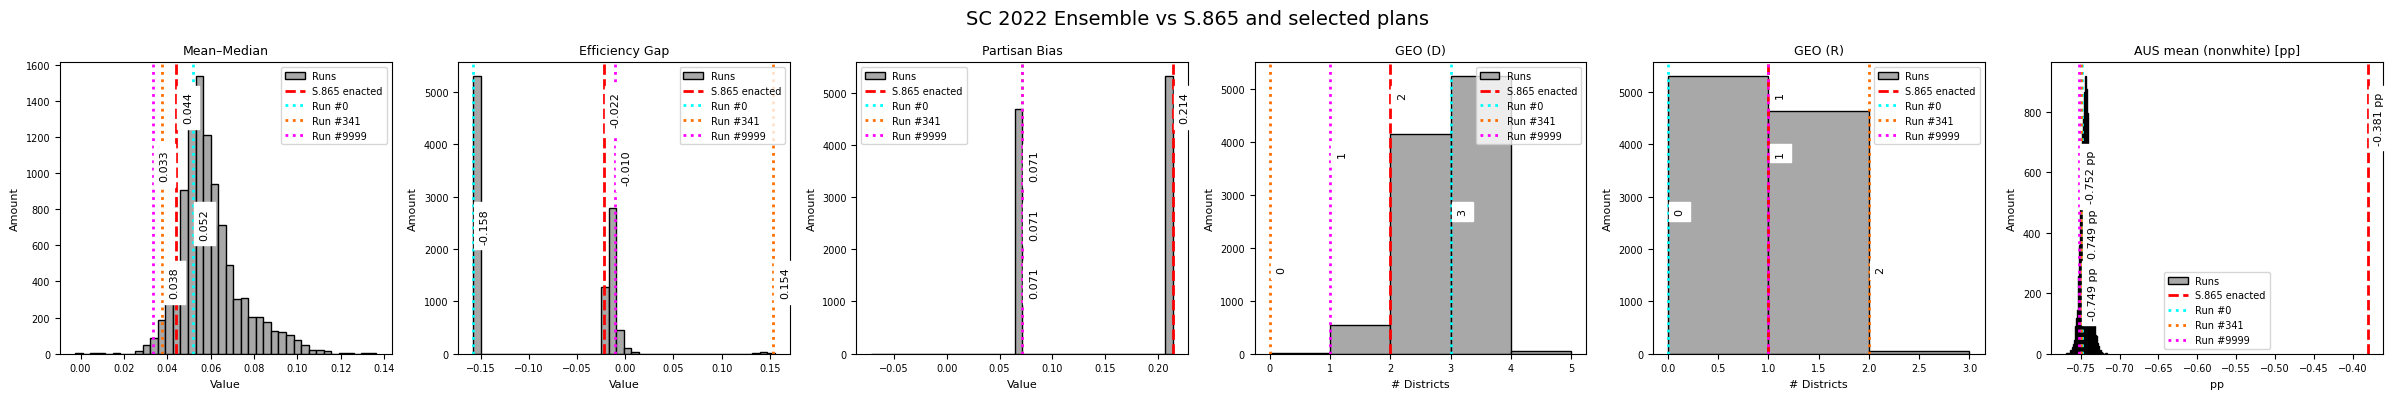

Saved: outputs\SC22\single_hists_with_overlays\hist_mean_median.png
Saved: outputs\SC22\single_hists_with_overlays\hist_efficiency_gap.png
Saved: outputs\SC22\single_hists_with_overlays\hist_partisan_bias.png
Saved: outputs\SC22\single_hists_with_overlays\hist_geo_D.png
Saved: outputs\SC22\single_hists_with_overlays\hist_geo_R.png
Saved: outputs\SC22\single_hists_with_overlays\hist_aus_nonwhite_mean_pp.png


In [ ]:
# DeFord-style histograms for SC ensemble
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias

# -Pick metrics_df
metrics_df = None
for cand in ["df_extra", "df_out", "df"]:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame) and not globals()[cand].empty:
        metrics_df = globals()[cand].copy()
        print(f"Using metrics_df from: {cand} (cols={list(metrics_df.columns)[:12]} …)")
        break

if metrics_df is None:
    raise ValueError("No metrics dataframe found (df_extra / df_out / df). Run the SC chain first.")

if "step" not in metrics_df.columns:
    raise KeyError("metrics_df has no 'step' column; cannot find sampled plan.")

# Enacted SC plan
if "part_s865" not in globals():
    raise KeyError("`part_s865` Partition (enacted S.865) not found. Build it before running this cell.")

part_enacted = part_s865

# Determine election alias 
if "PRES20" in part_enacted.updaters:
    ELECTION_ALIAS = "PRES20"
elif "pres20" in part_enacted.updaters:
    ELECTION_ALIAS = "pres20"
else:
    raise KeyError("Neither 'PRES20' nor 'pres20' updater is present on `part_s865`.")

# Enacted/seed metrics
enacted_metrics = {}
try:
    enacted_metrics["mean_median"]    = float(mean_median(part_enacted[ELECTION_ALIAS]))
    enacted_metrics["efficiency_gap"] = float(efficiency_gap(part_enacted[ELECTION_ALIAS]))
    enacted_metrics["partisan_bias"]  = float(partisan_bias(part_enacted[ELECTION_ALIAS]))
except Exception as e:
    print("[warn] Could not compute enacted fairness metrics:", e)

if "geo_D" in part_enacted.updaters and "geo_R" in part_enacted.updaters:
    enacted_metrics["geo_D"] = int(part_enacted["geo_D"])
    enacted_metrics["geo_R"] = int(part_enacted["geo_R"])

# Normalize column names in metrics_df
col_aliases = {
    "mean_median":    ["mean_median", "meanmedian"],
    "efficiency_gap": ["efficiency_gap", "effgap"],
    "partisan_bias":  ["partisan_bias", "bias50"],
    "geo_D":          ["geo_D"],
    "geo_R":          ["geo_R"],
}
for canon, options in col_aliases.items():
    if canon not in metrics_df.columns:
        for opt in options:
            if opt in metrics_df.columns:
                metrics_df[canon] = metrics_df[opt]
                break

# AUS 
aus_mean_cols = [
    c for c in metrics_df.columns
    if c.endswith("_mean_pp") and c.startswith("aus_")
]

# AUS + GEO-style integer metrics
int_metric_candidates = []
for c in metrics_df.columns:
    if c.startswith("aus_") and (c.endswith("_n_packed") or c.endswith("_n_cracked")):
        int_metric_candidates.append(c)
for c in ["geo_D", "geo_R"]:
    if c in metrics_df.columns and c not in int_metric_candidates:
        int_metric_candidates.append(c)

# Enacted AUS metrics 
aus_key = next((k for k in part_enacted.updaters.keys() if k.startswith("aus_")), None)
if aus_key is not None and aus_mean_cols:
    try:
        seg0 = part_enacted[aus_key]   # {dist: {"S_pm": ..., ...}}
        svals0 = np.array([v["S_pm"] for v in seg0.values()], dtype=float)

        # use the actual AUS mean column name from metrics_df, e.g. 'aus_black_mean_pp'
        aus_mean_name = aus_mean_cols[0]
        enacted_metrics[aus_mean_name] = float(np.nanmean(svals0))

        # packed/cracked counts -> non functional, keep for fix to do
        enacted_metrics.setdefault(f"{aus_key}_n_packed",  int((svals0 > 0).sum()))
        enacted_metrics.setdefault(f"{aus_key}_n_cracked", int((svals0 < 0).sum()))
    except Exception as e:
        print(f"[warn] Could not compute enacted S± metrics from '{aus_key}':", e)

print("Enacted S.865 metrics (fairness trio + GEO if present):")
for k in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"]:
    if k in enacted_metrics:
        print(f"  {k}: {enacted_metrics[k]}")

# 9999
SAMPLED_STEP = int(metrics_df["step"].max())
sample_row = metrics_df.loc[metrics_df["step"] == SAMPLED_STEP].iloc[0]

sample_metrics = {}
for m in metrics_df.columns:
    if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
       (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
        val = sample_row.get(m, np.nan)
        if pd.notna(val):
            sample_metrics[m] = float(val)

# First 0-seat and 2-seat
metrics_0 = {}
metrics_2 = {}
seat_col = "dem20_seats" if "dem20_seats" in metrics_df.columns else None

row0 = None
row2 = None
if seat_col is not None:
    df_seats = metrics_df.dropna(subset=[seat_col])

    if (df_seats[seat_col] == 0).any():
        row0 = df_seats.loc[df_seats[seat_col] == 0].sort_values("step").iloc[0]
        print("First 0-seat plan at step:", int(row0["step"]))
    else:
        print("No 0-seat plan found in this chain.")

    if (df_seats[seat_col] == 2).any():
        row2 = df_seats.loc[df_seats[seat_col] == 2].sort_values("step").iloc[0]
        print("First 2-seat plan at step:", int(row2["step"]))
    else:
        print("No 2-seat plan found in this chain.")

    if row0 is not None:
        for m in metrics_df.columns:
            if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
               (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
                val = row0.get(m, np.nan)
                if pd.notna(val):
                    metrics_0[m] = float(val)

    if row2 is not None:
        for m in metrics_df.columns:
            if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
               (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
                val = row2.get(m, np.nan)
                if pd.notna(val):
                    metrics_2[m] = float(val)

# -Decide which metrics to plot 
metrics_to_plot = []
for canon in ["mean_median", "efficiency_gap", "partisan_bias"]:
    if canon in metrics_df.columns:
        metrics_to_plot.append(canon)

for m in ["geo_D", "geo_R"]:
    if m in metrics_df.columns:
        metrics_to_plot.append(m)

for m in int_metric_candidates:
    if m in metrics_df.columns and m not in metrics_to_plot:
        metrics_to_plot.append(m)

metrics_to_plot.extend([m for m in aus_mean_cols if m not in metrics_to_plot])

if not metrics_to_plot:
    raise RuntimeError(
        "No metrics available to plot after normalization. "
        f"Columns are: {list(metrics_df.columns)}"
    )

# Pretty titles
pretty_map = {
    "geo_D": "GEO (D)",
    "geo_R": "GEO (R)",
    "mean_median": "Mean–Median",
    "efficiency_gap": "Efficiency Gap",
    "partisan_bias": "Partisan Bias",
}
for c in aus_mean_cols:
    group = c.replace("aus_", "").replace("_mean_pp", "")
    pretty_map[c] = f"AUS mean ({group}) [pp]"
for c in int_metric_candidates:
    if c not in pretty_map:
        if c.endswith("_n_packed"):
            pretty_map[c] = "S± packed (count)"
        elif c.endswith("_n_cracked"):
            pretty_map[c] = "S± cracked (count)"

# Multi-panel figure 
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 4))
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    if metric not in metrics_df.columns:
        ax.set_visible(False)
        continue

    series = metrics_df[metric].dropna()
    is_int_metric = metric in (["geo_D", "geo_R"] + int_metric_candidates)
    is_aus_mean   = metric in aus_mean_cols

    # Histogram bins
    if is_int_metric and len(series) > 0:
        lo, hi = int(series.min()), int(series.max())
        bins = np.arange(lo, hi + 2)
    else:
        bins = 40

    # Ensemble
    ax.hist(series, bins=bins, edgecolor="black", color="#A8A8A8", label="Runs")

    # S.865 
    if metric in enacted_metrics:
        val = enacted_metrics[metric]
        ax.axvline(val, color="red", linestyle="--", linewidth=2, label="S.865 enacted")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        offset = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(val):
            label_txt = f"{int(val)}"
        elif is_aus_mean and pd.notna(val):
            label_txt = f"{val:.3f} pp"
        else:
            label_txt = f"{val:.3f}" if pd.notna(val) else "n/a"
        ax.text(val + offset, ylim[1] * 0.9, label_txt,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # First 0-seat
    if metric in metrics_0:
        v0 = metrics_0[metric]
        ax.axvline(v0, color="cyan", linestyle=":", linewidth=2, label="Run #0")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        off0 = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(v0):
            txt0 = f"{int(v0)}"
        elif is_aus_mean and pd.notna(v0):
            txt0 = f"{v0:.3f} pp"
        else:
            txt0 = f"{v0:.3f}" if pd.notna(v0) else "n/a"
        ax.text(v0 + off0, ylim[1] * 0.5, txt0,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # First 2-seat
    if metric in metrics_2:
        v2 = metrics_2[metric]
        ax.axvline(v2, color="#FF6F00", linestyle=":", linewidth=2, label="Run #341")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        off2 = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(v2):
            txt2 = f"{int(v2)}"
        elif is_aus_mean and pd.notna(v2):
            txt2 = f"{v2:.3f} pp"
        else:
            txt2 = f"{v2:.3f}" if pd.notna(v2) else "n/a"
        ax.text(v2 + off2, ylim[1] * 0.3, txt2,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # 9999
    if metric in sample_metrics:
        sval = sample_metrics[metric]
        ax.axvline(sval, color="magenta", linestyle=":", linewidth=2,
                   label=f"Run #{SAMPLED_STEP}")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        soffset = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(sval):
            slabel_txt = f"{int(sval)}"
        elif is_aus_mean and pd.notna(sval):
            slabel_txt = f"{sval:.3f} pp"
        else:
            slabel_txt = f"{sval:.3f}" if pd.notna(sval) else "n/a"
        ax.text(sval + soffset, ylim[1] * 0.7, slabel_txt,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    pretty_name = pretty_map.get(metric, metric.replace("_", " ").title())
    ax.set_title(pretty_name)
    ax.set_xlabel("# Districts" if is_int_metric else ("pp" if is_aus_mean else "Value"))
    ax.set_ylabel("Amount")
    ax.legend(loc="best")

plt.suptitle("SC 2022 Ensemble vs S.865 and selected plans", fontsize=14)
out_root = Path("./outputs/SC22")
out_root.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(out_root / "sc22_ensemble_histograms_with_enacted_and_samples.png", dpi=200)
print("Saved:", out_root / "sc22_ensemble_histograms_with_enacted_and_samples.png")
plt.show()

# Save each metric histogram separately
single_dir = out_root / "single_hists_with_overlays"
single_dir.mkdir(parents=True, exist_ok=True)

for metric in metrics_to_plot:
    if metric not in metrics_df.columns:
        continue

    series = metrics_df[metric].dropna()
    is_int_metric = metric in (["geo_D", "geo_R"] + int_metric_candidates)
    is_aus_mean   = metric in aus_mean_cols

    # Binning
    if is_int_metric and len(series) > 0:
        lo, hi = int(series.min()), int(series.max())
        bins = np.arange(lo, hi + 2)
    else:
        bins = 40

    fig_m, ax_m = plt.subplots(figsize=(5.5, 4))

    # Ensemble 
    ax_m.hist(series, bins=bins, edgecolor="black", color="#A8A8A8", label="Runs")

    # Enacted S.865
    if metric in enacted_metrics:
        val = enacted_metrics[metric]
        ax_m.axvline(val, color="red", linestyle="--", linewidth=2, label="S.865 enacted")

    # First 0-seat 
    if metric in metrics_0:
        v0 = metrics_0[metric]
        ax_m.axvline(v0, color="cyan", linestyle=":", linewidth=2, label="Run #0")

    # First 2-seat 
    if metric in metrics_2:
        v2 = metrics_2[metric]
        ax_m.axvline(v2, color="#FF6F00", linestyle=":", linewidth=2, label="Run #341")

    # 9999
    if metric in sample_metrics:
        sval = sample_metrics[metric]
        ax_m.axvline(sval, color="magenta", linestyle=":", linewidth=2,
                     label=f"Run #{SAMPLED_STEP}")

    # Titles 
    pretty_name = pretty_map.get(metric, metric.replace("_", " ").title())
    ax_m.set_title(pretty_name)
    ax_m.set_xlabel("# Districts" if is_int_metric else ("pp" if is_aus_mean else "Value"))
    ax_m.set_ylabel("Amount")

    # tight_layout
    fig_m.tight_layout()

    # Shrink axes 
    box = ax_m.get_position()
    ax_m.set_position([box.x0, box.y0, box.width * 0.78, box.height])

    # Legend inside figure margin 
    ax_m.legend(
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False
    )

    # Save
    out_path = single_dir / f"hist_{metric}.png"
    fig_m.savefig(out_path, dpi=200)
    plt.close(fig_m)
    print("Saved:", out_path)



# 4. extra study area maps

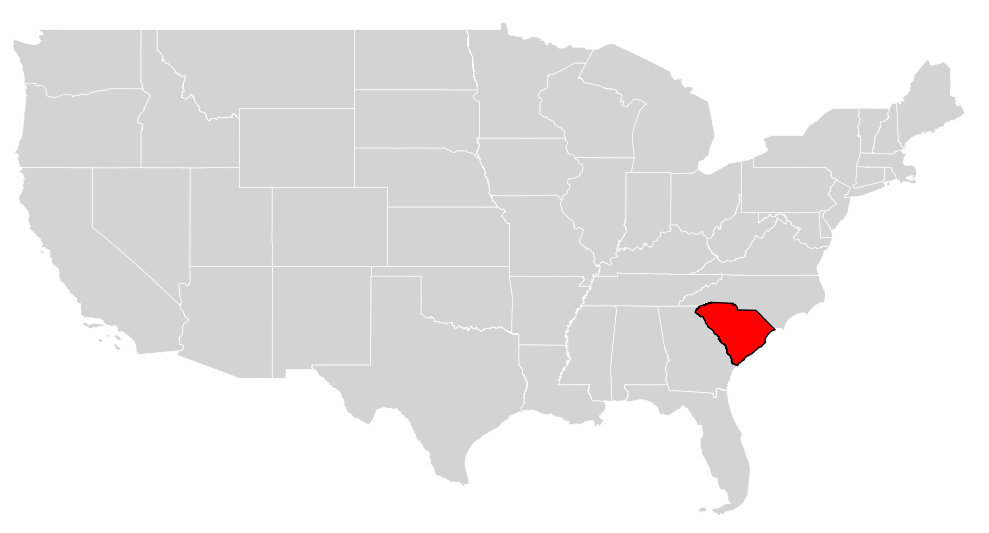

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

US_STATES_FP = r"E:\wur_mgi-thesis_method_outlier-analysis\inputs\SC\tl_2025_us_state\tl_2025_us_state.shp"

# Load states
us_states = gpd.read_file(US_STATES_FP, engine="pyogrio")

# Select South Carolina
sc = us_states[us_states["NAME"].str.upper() == "SOUTH CAROLINA"]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

us_states.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5,
    zorder=1
)

sc.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=1.0,
    zorder=2
)

# Continental US extent 
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.axis("off")
plt.tight_layout()
plt.show()




C:\Users\kubak\AppData\Local\Temp\ipykernel_56144\948220001.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


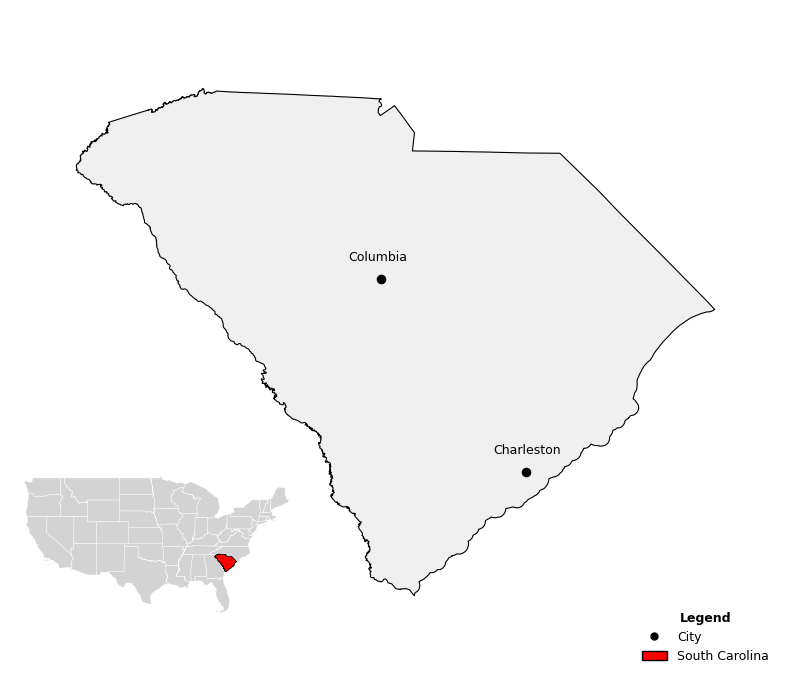

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# paths

US_STATES_FP = r"E:\wur_mgi-thesis_method_outlier-analysis\inputs\SC\tl_2025_us_state\tl_2025_us_state.shp"

# Load 
us_states = gpd.read_file(US_STATES_FP, engine="pyogrio")

sc = us_states[us_states["NAME"].str.upper() == "SOUTH CAROLINA"]

# Cities (lon, lat) fixed coordinates

cities = gpd.GeoDataFrame(
    {
        "city": ["Charleston", "Columbia"],
        "geometry": [
            Point(-79.9311, 32.7765),  # Charleston
            Point(-81.0348, 34.0007),  # Columbia
        ],
    },
    crs="EPSG:4326",
)

# Figure
fig, ax = plt.subplots(figsize=(8, 8))

# Main map: South Carolina
sc.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="black",
    linewidth=0.8,
    zorder=1,
)

# City dots
cities.plot(
    ax=ax,
    color="black",
    markersize=35,
    zorder=3,
)

# City labels
for x, y, label in zip(
    cities.geometry.x, cities.geometry.y, cities["city"]
):
    ax.text(
        x - 0.25,
        y + 0.10,
        label,
        fontsize=9,
        ha="left",
        va="bottom",
    )

# Set tight extent
minx, miny, maxx, maxy = sc.total_bounds
ax.set_xlim(minx - 0.5, maxx + 0.5)
ax.set_ylim(miny - 0.5, maxy + 0.5)

ax.axis("off")

# Inset
axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    loc="lower left",
    borderpad=1,
)

us_states.plot(
    ax=axins,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.3,
)

sc.plot(
    ax=axins,
    color="red",
    edgecolor="black",
    linewidth=0.6,
)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

city_handle = Line2D(
    [0], [0],
    marker="o",
    linestyle="None",
    markerfacecolor="black",
    markeredgecolor="none",
    markersize=6,
)

state_handle = Patch(
    facecolor="red",
    edgecolor="black",
)

leg = ax.legend(
    handles=[city_handle, state_handle],
    labels=["City", "South Carolina"],
    title="Legend",
    loc="lower right",
    frameon=False,
    fontsize=9,
)

leg.get_title().set_fontsize(9)
leg.get_title().set_fontweight("bold")

# Continental US extent
axins.set_xlim(-125, -66)
axins.set_ylim(24, 50)

axins.axis("off")

plt.tight_layout()
plt.show()




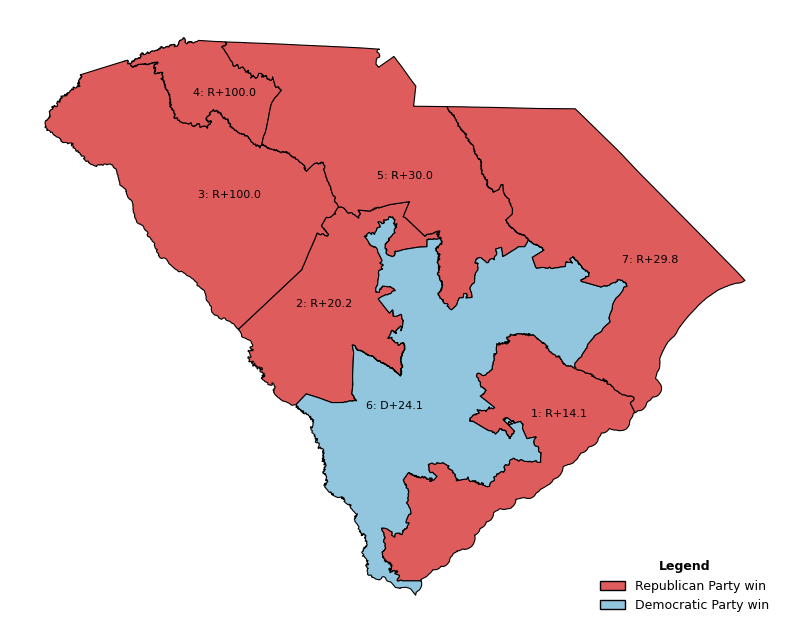

In [ ]:
import re
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Files
PREC_FP = r"./inputs/SC/sc_2022_gen_prec/sc_2022_gen_cong_prec/sc_2022_gen_cong_prec.shp"
DIST_FP = r"./inputs/SC/sc_cong_adopted_2022/S865_Congress.shp"

# Colors 
DEM_COLOR = "#92c5de"   # Democratic (light blue)
REP_COLOR = "#df5c5c"   # Republican (light red)

# Load 
prec = gpd.read_file(PREC_FP, engine="pyogrio")
dists = gpd.read_file(DIST_FP, engine="pyogrio")

if prec.crs is None:
    prec = prec.set_crs("EPSG:4326")
if dists.crs is None:
    dists = dists.set_crs("EPSG:4326")
if prec.crs != dists.crs:
    prec = prec.to_crs(dists.crs)


# US House vote columns
dem_cols = [c for c in prec.columns if re.fullmatch(r"GCON\d{2}D.*", c)]
rep_cols = [c for c in prec.columns if re.fullmatch(r"GCON\d{2}R.*", c)]

prec["VOTE_D"] = prec[dem_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
prec["VOTE_R"] = prec[rep_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
prec["VOTE_TOT"] = prec["VOTE_D"] + prec["VOTE_R"]
prec = prec[prec["VOTE_TOT"] > 0]


# join 
prec_pts = prec.copy()
prec_pts["geometry"] = prec_pts.geometry.representative_point()

joined = gpd.sjoin(
    prec_pts[["VOTE_D", "VOTE_R", "VOTE_TOT", "geometry"]],
    dists,
    how="left",
    predicate="within",
)

# istrict ID column
for c in ["USCD", "DISTRICT", "CD", "CONG_DIST", "DIST"]:
    if c in joined.columns:
        DIST_COL = c
        break
else:
    raise ValueError("District ID column not found.")

# Aggregate votes to district 
agg = (
    joined.groupby(DIST_COL)[["VOTE_D", "VOTE_R", "VOTE_TOT"]]
    .sum()
    .reset_index()
)

agg["WINNER"] = agg.apply(lambda r: "D" if r["VOTE_D"] > r["VOTE_R"] else "R", axis=1)
agg["MARGIN"] = (
    abs(agg["VOTE_D"] - agg["VOTE_R"]) / agg["VOTE_TOT"] * 100
)

agg["LABEL"] = agg.apply(
    lambda r: f"{int(r[DIST_COL])}: {r['WINNER']}+{r['MARGIN']:.1f}",
    axis=1,
)

d_map = dists.merge(agg, on=DIST_COL, how="left")


# Plot
fig, ax = plt.subplots(figsize=(8, 8))

colors = d_map["WINNER"].map({"D": DEM_COLOR, "R": REP_COLOR})
d_map.plot(ax=ax, color=colors, edgecolor="black", linewidth=0.8)

# Labels
label_pts = d_map.copy()
label_pts["geometry"] = label_pts.geometry.representative_point()

for _, r in label_pts.dropna(subset=["LABEL"]).iterrows():

    # Default: no offset
    dx, dy = 0.0, 0.0

    # Manual nudge for District 1 only -> PAIN
    if int(r[DIST_COL]) == 1:
        dx, dy = 0.0, 0.25  

    ax.text(
        r.geometry.x + dx,
        r.geometry.y + dy,
        r["LABEL"],
        fontsize=8,
        ha="center",
        va="center",
        zorder=10,
    )

ax.axis("off")


# Legend
legend_handles = [
    Patch(facecolor=REP_COLOR, edgecolor="black", label="Republican Party win"),
    Patch(facecolor=DEM_COLOR, edgecolor="black", label="Democratic Party win"),
]

leg = ax.legend(
    handles=legend_handles,
    title="Legend",
    loc="lower right",
    frameon=False,
    fontsize=9,
)

leg.get_title().set_fontsize(9)
leg.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()
